# Libraries

In [503]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

import statistics
# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [504]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2026\20260402_60Ag_RT_K2SO4-water_H2SO4anolyte

13-Aug-26  02:13 PM    <DIR>          .
18-Apr-26  10:11 AM    <DIR>          ..
08-Apr-26  03:18 PM    <DIR>          .ipynb_checkpoints
22-Apr-26  07:31 PM             1,162 20260402 - Ag60 GDE_RT_K2SO4-water_pH3.csv
13-Aug-26  02:13 PM           993,367 20260402 - Ag60 GDE_RT_K2SO4-water_pH3.ipynb
09-Apr-26  12:39 PM             1,142 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_CORRECTED.csv
13-Aug-26  01:02 PM               614 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_Energy Consumption.csv
22-Apr-26  07:32 PM           124,871 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(CO)vsCD_SEM.png
22-Apr-26  07:32 PM           130,787 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(H2)vsCD_SEM.png
22-Apr-26  07:32 PM           107,463 20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(O2)vsCD_SEM.png
25-Apr-2

# Load Data

In [505]:
Book = "Book_20260402_Ag60 GDE_RT_K2SO4-water_pH3.xlsx"
Book_o2 = "Book_20260402_Ag60 GDE_RT_K2SO4-water_pH3 - O2.xlsx"
Book = pd.read_excel(Book)
Book_o2 = pd.read_excel(Book_o2)
Book.head(3)
Book.drop(['Electrode','Catholyte','Anolyte', 'Membrane', 'area(CH4)',
       'Unnamed: 24', 'Unnamed: 25', 'uGC', 'Unnamed: 27','FE(CH4)', 'Total FE', 'Carbon efficiency'], axis='columns', inplace=True)
Book_o2.drop(['Electrode','Catholyte','Anolyte', 'Membrane', 'area(CO2)', 'area(CH4)',
              'c(CO2)', 'Unnamed: 24', 'Unnamed: 25', 'uGC', 'Unnamed: 27','FE(CH4)', 'Total FE', 'Carbon efficiency'], axis='columns', inplace=True)
Book.columns
Book_o2.columns


Book_cathode_GC = pd.read_excel("Book_cathode_GC times.xlsx")

Book_anode_GC = pd.read_excel("Book_anode_GC times.xlsx")

#### Temp from pH meter

In [506]:
Temp_C_median = 21.4

### Power Supply

In [507]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(10)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,"0,00V","0,00V","0,000A","0,000A","320,00W","0,00W",N/AR,NaN,NaN,On,CV,NaN,02-04-26 16:36
1,"40,00V","2,11V","0,100A","0,102A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:36
2,"40,00V","2,14V","0,100A","0,101A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:37
3,"40,00V","2,15V","0,100A","0,098A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:37
4,"40,00V","2,16V","0,100A","0,099A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:38
5,"40,00V","2,17V","0,100A","0,099A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:38
6,"40,00V","2,17V","0,100A","0,101A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:39
7,"40,00V","2,19V","0,100A","0,102A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:39
8,"40,00V","2,19V","0,100A","0,098A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:40
9,"40,00V","2,20V","0,100A","0,102A","320,00W","0,00W",N/AR,NaN,NaN,On,CC,NaN,02-04-26 16:40


In [508]:
power_sup.groupby("I set", group_keys=True)[["U actual"]].apply(lambda x: x)

U actual
I set              
0,000A 0      0,00V
0,100A 1      2,11V
       2      2,14V
       3      2,15V
       4      2,16V
...             ...
3,000A 315    4,71V
       316    4,78V
       317    4,74V
       318    4,81V
       319    4,76V

[320 rows x 1 columns]

In [509]:
# Fix possible wrong separator in milliseconds (e.g. 16:58:21/004 -> 16:58:21.004)
power_sup["Time"] = power_sup["Time"].astype(str).str.replace(
    r"(\d{2}:\d{2}:\d{2})/(\d+)$",
    r"\1.\2",
    regex=True
)

# Convert Time column
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="mixed",
    dayfirst=True
)

# Convert current and voltage to numbers
power_sup["I actual"] = (
    power_sup["I actual"]
    .astype(str)
    .str.replace("A", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .astype(float)
)

power_sup["U actual"] = (
    power_sup["U actual"]
    .astype(str)
    .str.replace("V", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Max current and voltage every 20 min
power_summary = (
    power_sup.resample("20min")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

print(power_summary)

                 Time  I actual  U actual
0 2026-04-02 16:20:00     0.102      2.19
1 2026-04-02 16:40:00     0.255      2.55
2 2026-04-02 17:00:00     0.501      3.03
3 2026-04-02 17:20:00     1.001      3.59
4 2026-04-02 17:40:00     1.505      3.95
5 2026-04-02 18:00:00     2.007      4.24
6 2026-04-02 18:20:00     2.505      4.46
7 2026-04-02 18:40:00     3.004      4.72
8 2026-04-02 19:00:00     3.005      4.81


In [510]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-1].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2026-04-02 16:20:00     0.102      2.19
1 2026-04-02 16:40:00     0.255      2.55
2 2026-04-02 17:00:00     0.501      3.03
3 2026-04-02 17:20:00     1.001      3.59
4 2026-04-02 17:40:00     1.505      3.95
5 2026-04-02 18:00:00     2.007      4.24
6 2026-04-02 18:20:00     2.505      4.46
7 2026-04-02 18:40:00     3.004      4.72


In [511]:
# power_sup["U actual"] = (power_sup["U actual"].str.replace("V", "", regex=False).str.replace(",", ".", regex=False).astype(float))
# power_sup["I set"] = (power_sup["I set"].str.replace("A", "", regex=False).str.replace(",", ".", regex=False).astype(float))

# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [512]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.102,2.19
0.255,2.55
0.501,3.03
1.001,3.59
1.505,3.95
2.007,4.24
2.505,4.46
3.004,4.72


In [513]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.102,2.19,1.02
0.255,2.55,2.55
0.501,3.03,5.01
1.001,3.59,10.01
1.505,3.95,15.05
2.007,4.24,20.07
2.505,4.46,25.05
3.004,4.72,30.04


In [514]:
# dfcell_voltage[["I actual", "area(H2)", "c(H2)", "area(CO)", "c(CO)"]].head(10)

## FLow rate

In [515]:
flow_rate = "Anolyte_RT_60Ag_H2SO4_20260402_1953_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")

flow_rate_cat = "K2SO4_RT__60Ag_pH3_20260402_1954_1min.xlsx"
flow_rate_cat = pd.read_excel(flow_rate_cat, sheet_name="Process data")

flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2026-04-02 19:53:52.685000,NaN
1,Software version,Aurora 1.2.6,NaN
2,Instrument name,Anolyte_RT_60Ag_H2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:ab:cd:f0,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [516]:
flow_rate = flow_rate.iloc[19:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate_cat = flow_rate_cat.iloc[19:].reset_index(drop=True)
flow_rate_cat = flow_rate_cat.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate_cat

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2026-04-02 14:35:59.971000,50.914146,25.457073
1,2026-04-02 14:37:00.019000,50.113241,25.05662
2,2026-04-02 14:37:59.981000,48.487726,24.243863
3,2026-04-02 14:39:00.029000,48.243689,24.121845
4,2026-04-02 14:39:59.990000,49.726205,24.863102
...,...,...,...
314,2026-04-02 19:50:00.010000,43.705453,21.852726
315,2026-04-02 19:50:59.971000,44.477103,22.238551
316,2026-04-02 19:52:00.019000,46.108123,23.054062
317,2026-04-02 19:52:59.981000,42.448959,21.224479


In [517]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 20min
flow_rate = (
    flow_rate.resample("20min")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

flow_rate_cat["Time (UTC)"] = pd.to_datetime(
    flow_rate_cat["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate_cat = flow_rate_cat.set_index("Time (UTC)")

# Mean current and voltage every 20min
flow_rate_cat = (
    flow_rate_cat.resample("20min")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate_cat)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2026-04-02 14:20:00     48.243689     50.914146      49.497001   
1  2026-04-02 14:40:00     47.922088     51.425497      49.265516   
2  2026-04-02 15:00:00     48.794644     54.490949      51.094302   
3  2026-04-02 15:20:00     49.379256     55.029891      51.886543   
4  2026-04-02 15:40:00     49.711334     56.374585      52.101799   
5  2026-04-02 16:00:00     52.067205     58.061714      54.621267   
6  2026-04-02 16:20:00     55.262782     60.235318      57.550614   
7  2026-04-02 16:40:00     56.455112     64.775951      59.960926   
8  2026-04-02 17:00:00     40.750815     64.734888      58.799437   
9  2026-04-02 17:20:00     43.055244     47.290686      45.080368   
10 2026-04-02 17:40:00     43.923956      45.92413      44.997798   
11 2026-04-02 18:00:00     45.275642     48.428358      46.321856   
12 2026-04-02 18:20:00     45.026571      48.16656      46.584799   
13 2026-04-02 18:40:00     44.3129

### Correction for dry flow

In [518]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.169 L/mol
p_sat = 2.5490 kPa -> x(H2O) = 2.52 % -> dry factor 0.97484


In [519]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY


FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate_cat[c + "_dry"] = flow_rate_cat[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [520]:
print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2026-04-02 14:20:00           0.0           0.0            0.0   
1  2026-04-02 14:40:00           0.0      2.206506       0.351526   
2  2026-04-02 15:00:00      0.545595      1.207793       0.647464   
3  2026-04-02 15:20:00      1.140872      2.529292       1.339437   
4  2026-04-02 15:40:00      2.157447      3.464899       2.428201   
5  2026-04-02 16:00:00      3.189331      4.941414        3.58702   
6  2026-04-02 16:20:00      4.252924      5.689627       4.664635   
7  2026-04-02 16:40:00       5.30972      6.790139       5.692713   
8  2026-04-02 17:00:00       0.02571      6.799082       5.318126   
9  2026-04-02 17:20:00       0.02571       0.02571        0.02571   
10 2026-04-02 17:40:00       0.02571       0.02571        0.02571   
11 2026-04-02 18:00:00       0.02571       0.02571        0.02571   
12 2026-04-02 18:20:00       0.02571      0.036582       0.027054   
13 2026-04-02 18:40:00      0.0365

In [521]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-8].reset_index(drop=True)

dfflow_rate_cat = pd.DataFrame(flow_rate_cat)
dfflow_rate_cat['Current [A]'] = power_summary['I actual']
dfflow_rate_cat['Voltage'] = power_summary['U actual']
dfflow_rate_cat = dfflow_rate_cat.iloc[:-9].reset_index(drop=True)
dfflow_rate_cat


dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2026-04-02 14:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.102,2.19
1,2026-04-02 14:40:00,0.0,2.206506,0.351526,0.255653,0.0,2.150998,0.342683,0.249222,0.255,2.55
2,2026-04-02 15:00:00,0.545595,1.207793,0.647464,0.564703,0.53187,1.177409,0.631176,0.550497,0.501,3.03
3,2026-04-02 15:20:00,1.140872,2.529292,1.339437,1.183537,1.112172,2.465664,1.305742,1.153764,1.001,3.59
4,2026-04-02 15:40:00,2.157447,3.464899,2.428201,2.29517,2.103173,3.377735,2.367116,2.237432,1.505,3.95
5,2026-04-02 16:00:00,3.189331,4.941414,3.58702,3.425621,3.109099,4.817106,3.496783,3.339445,2.007,4.24
6,2026-04-02 16:20:00,4.252924,5.689627,4.664635,4.543821,4.145936,5.546497,4.547289,4.429515,2.505,4.46
7,2026-04-02 16:40:00,5.30972,6.790139,5.692713,5.526359,5.176147,6.619324,5.549505,5.387335,3.004,4.72


In [522]:
# dfflow_rate

In [523]:
# dfflow_rate.to_csv('20260402_0.6M K2SO4_pH3_flow rate_anode.csv')
# dfflow_rate_cat.to_csv('20260402_0.6M K2SO4_pH3_flow rate_cathode.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 3hr = 10800s <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [524]:
electrode_area = 10/10000 #10cm2 to m2
time = 20*60 #20min

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.102,2.19,1.02,102.0
0.255,2.55,2.55,255.0
0.501,3.03,5.01,501.0


In [525]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.102,2.19,1.02,102.0,268.056
0.255,2.55,2.55,255.0,780.300
0.501,3.03,5.01,501.0,1821.636
1.001,3.59,10.01,1001.0,4312.308
1.505,3.95,15.05,1505.0,7133.700
2.007,4.24,20.07,2007.0,10211.616
2.505,4.46,25.05,2505.0,13406.760
3.004,4.72,30.04,3004.0,17014.656


In [526]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.102,2.19,1.02,102.0,268.056,0.000074
0.255,2.55,2.55,255.0,780.300,0.000217
0.501,3.03,5.01,501.0,1821.636,0.000506
1.001,3.59,10.01,1001.0,4312.308,0.001198
1.505,3.95,15.05,1505.0,7133.700,0.001982
2.007,4.24,20.07,2007.0,10211.616,0.002837
2.505,4.46,25.05,2505.0,13406.760,0.003724
3.004,4.72,30.04,3004.0,17014.656,0.004726


In [527]:
# dfcell_voltage.to_csv('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [528]:
# Book["time_min"] = np.arange(len(Book["area(H2)"]))
# cycle = Book["time_min"] % 8
# run_mask = cycle < 4
# # gas_cols = ["area(H2)", "area(CO2)", "area(CO)", "area(O2)"]
# # Book.loc[~run_mask, gas_cols] = np.nan
# Book.tail(5)

# Book[["Applied current / A", "area(H2)", "c(H2)", "area(CO)", "c(CO)"]].tail(10)

Book["Time_20min"] = np.floor(Book["Duration / h"] / (20/60))

Book = Book[Book["Time_20min"].notna()].copy()



Book_o2["Time_20min"] = np.floor(Book_o2["Duration / h"] / (20/60))
Book_o2 = Book_o2[Book_o2["Time_20min"].notna()].copy()
Book_o2



,Inlet flow rate,Flow rate (ml min-1),Applied current / A,Time,Duration / h,area(H2),area(CO),area(O2),area(N2),c(H2),c(CO),c(O2),FE(H2),FE(CO),Time_20min
0,60,0.000000,0.00,2026-04-02 16:36:20,0.000000,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,60,0.000000,-0.10,2026-04-02 16:36:50,0.008333,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,60,0.000000,-0.25,2026-04-02 16:37:20,0.016667,65292.0,3506543.0,30519923.0,18103619.0,0.000144,0.080803,0.554870,0.0,0.0,0.0
3,60,0.000000,-0.25,2026-04-02 16:37:50,0.025000,67739.0,3562365.0,30831092.0,17752974.0,0.000149,0.082089,0.560686,0.0,0.0,0.0
4,60,0.000000,-0.25,2026-04-02 16:38:20,0.033333,76980.0,3717408.0,31403300.0,17093417.0,0.000169,0.085662,0.570069,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,60,6.558127,-0.50,2026-04-02 19:13:53,2.625833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
316,60,6.742154,-0.50,2026-04-02 19:14:23,2.634167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
317,60,6.742154,-0.50,2026-04-02 19:14:53,2.642500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
318,60,6.767250,-0.50,2026-04-02 19:15:23,2.650833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0


In [529]:
# ---------------------------------------------------------------------------
# 1) which rows are the anode?  The GC alternates cathode / anode,
#    so O2 should appear on every other row.
# ---------------------------------------------------------------------------
print(Book_o2[["area(H2)", "area(CO)", "area(O2)"]].head(10))
print("\nO2 present on even rows:", (Book_o2["area(O2)"].fillna(0).iloc[0::2] > 0).sum(),
      " odd rows:",               (Book_o2["area(O2)"].fillna(0).iloc[1::2] > 0).sum())


print(Book[["area(H2)", "area(CO)"]].head(10))

   area(H2)   area(CO)    area(O2)
0       0.0        0.0         0.0
1       0.0        0.0         0.0
2   65292.0  3506543.0  30519923.0
3   67739.0  3562365.0  30831092.0
4   76980.0  3717408.0  31403300.0
5   84065.0  3788019.0  31812620.0
6   93986.0  3895990.0  32529834.0
7   95936.0  3986141.0  32716941.0
8  102889.0  3955282.0  33288710.0
9  100358.0  4116672.0  33169595.0

O2 present on even rows: 23  odd rows: 22
     area(H2)  area(CO)
0         0.0       0.0
1     21223.0       0.0
2    251318.0       0.0
3      1042.0       0.0
4  10172936.0       0.0
5  10888436.0       0.0
6  19199064.0       0.0
7  20801421.0       0.0
8  25520785.0   97386.0
9  29560585.0  286248.0


In [530]:
# print(Book_o2.columns.tolist())
# print(len(Book_o2))

In [531]:
# --- dfflow_rate: build a minutes axis from the UTC timestamps ---
dfr = dfflow_rate.copy()
dfr["t"] = pd.to_datetime(dfr["Time (UTC)"], errors="coerce")
dfr = dfr.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

T0 = dfr["t"].iloc[0]
dfr["Duration / min"] = (dfr["t"] - T0).dt.total_seconds() / 60

print(dfr[["t", "Duration / min"]].head(10))
print("columns:", dfr.columns.tolist())

                    t  Duration / min
0 2026-04-02 14:20:00             0.0
1 2026-04-02 14:40:00            20.0
2 2026-04-02 15:00:00            40.0
3 2026-04-02 15:20:00            60.0
4 2026-04-02 15:40:00            80.0
5 2026-04-02 16:00:00           100.0
6 2026-04-02 16:20:00           120.0
7 2026-04-02 16:40:00           140.0
columns: ['Time (UTC)', 'Flow_rate_min', 'Flow_rate_max', 'Flow_rate_mean', 'Flow_rate_median', 'Flow_rate_min_dry', 'Flow_rate_max_dry', 'Flow_rate_mean_dry', 'Flow_rate_median_dry', 'Current [A]', 'Voltage', 't', 'Duration / min']


In [532]:
cur = dfr["Current [A]"].abs().round(2)      # adjust the name if it differs
t   = dfr["Duration / min"]

step_id = (cur.diff().abs() > 1e-3).cumsum()
steps = (pd.DataFrame({"step": step_id, "I": cur, "t": t})
           .groupby("step").agg(I=("I", "median"),
                                t_start=("t", "min"), t_end=("t", "max"))
           .reset_index(drop=True))
steps = steps[steps["I"] > 0].reset_index(drop=True)
steps["dur_min"] = steps["t_end"] - steps["t_start"]
print(steps.round(2))

run_min = steps["t_end"].max() - steps["t_start"].min()
print(f"\nrun {run_min:.1f} min, {len(Book_o2)} GC rows "
      f"-> {run_min/max(len(Book_o2)-1, 1):.2f} min per injection")

      I  t_start  t_end  dur_min
0  0.10      0.0    0.0      0.0
1  0.26     20.0   20.0      0.0
2  0.50     40.0   40.0      0.0
3  1.00     60.0   60.0      0.0
4  1.50     80.0   80.0      0.0
5  2.01    100.0  100.0      0.0
6  2.50    120.0  120.0      0.0
7  3.00    140.0  140.0      0.0

run 140.0 min, 320 GC rows -> 0.44 min per injection


In [533]:
print(len(Book), Book.columns.tolist())
print(Book[["area(H2)","area(CO)"]].head(20))
print("rows with a peak:",
      ((Book["area(CO)"].fillna(0)>0)|(Book["area(H2)"].fillna(0)>0)).sum())

320 ['Inlet flow rate', 'Flow rate (ml min-1)', 'Applied current / A', 'Time', 'Duration / h', 'area(H2)', 'area(CO)', 'area(CO2)', 'area(O2)', 'area(N2)', 'c(H2)', 'c(CO)', 'c(CO2)', 'c(O2)', 'FE(H2)', 'FE(CO)', 'Time_20min']
      area(H2)   area(CO)
0          0.0        0.0
1      21223.0        0.0
2     251318.0        0.0
3       1042.0        0.0
4   10172936.0        0.0
5   10888436.0        0.0
6   19199064.0        0.0
7   20801421.0        0.0
8   25520785.0    97386.0
9   29560585.0   286248.0
10  33210954.0   545291.0
11  33801918.0   613752.0
12  40730637.0  2632164.0
13  41219384.0  2776798.0
14  49809031.0  3593448.0
15  52914568.0  3909363.0
16  56570920.0  4208962.0
17  61700452.0  4349147.0
18  73421269.0  4678970.0
19  74629770.0  4720079.0
rows with a peak: 46


In [534]:
for name, df in [("cathode", Book_cathode_GC), ("anode", Book_anode_GC)]:
    print(f"--- {name}: {df.shape} ---")
    print(df.columns.tolist())
    print(df.head(3).to_string())
    print()

print("--- dfflow_rate:", dfflow_rate.shape, "---")
print(dfflow_rate.columns.tolist())
print(dfflow_rate.head(3).to_string())

--- cathode: (48, 6) ---
['Time', 'H2', 'O2', 'N2', 'CH4', 'CO']
       Time        H2      O2    N2  CH4          CO
0  14:24:34  95219579   55710   858  315      101338
1  14:28:05     24876  231675   827  174            
2  14:38:42     21223  208511  1010  137            

--- anode: (47, 6) ---
['Time', 'H2', 'O2', 'N2', 'CH4', 'CO']
       Time     H2        O2        N2  CH4       CO
0  14:31:44  63052  30455852  18143959  192  3495275
1  14:35:13  62142  30448175  18183127  138  3469973
2  14:45:45  65292  30519923  18103619  238  3506543

--- dfflow_rate: (8, 11) ---
['Time (UTC)', 'Flow_rate_min', 'Flow_rate_max', 'Flow_rate_mean', 'Flow_rate_median', 'Flow_rate_min_dry', 'Flow_rate_max_dry', 'Flow_rate_mean_dry', 'Flow_rate_median_dry', 'Current [A]', 'Voltage']
           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry Flow_rate_median_dry  Current [A]  Voltage
0 2026-04-02 14:20:00           0.0 

In [543]:
DATE = "2026-04-02"

##### Give each GC injection the current/voltage/flow of the step it falls in. ######

def attach_steps(gc, steps):
    g = gc.copy()
    g["t"] = pd.to_datetime(DATE + " " + g["Time"].astype(str))
    for c in ["H2", "O2", "N2", "CH4", "CO"]:
        g[c] = pd.to_numeric(g[c], errors="coerce").fillna(0)   # blanks -> 0
    g = g.sort_values("t")

    s = steps.copy()
    s["t"] = pd.to_datetime(s["Time (UTC)"])
    s = s.sort_values("t")

    out = pd.merge_asof(g, s[["t", "Current [A]", "Voltage",
                              "Flow_rate_median_dry", "Flow_rate_mean_dry"]],
                        on="t", direction="backward")     # step start -> forward
    return out.dropna(subset=["Current [A]"])

cath = attach_steps(Book_cathode_GC, dfflow_rate_cat)
an   = attach_steps(Book_anode_GC,   dfflow_rate)

print(cath.groupby("Current [A]").size().rename("cathode injections"))
print(an.groupby("Current [A]").size().rename("anode injections"))
print(f"\ncathode {cath.t.min():%H:%M} - {cath.t.max():%H:%M}   "
      f"anode {an.t.min():%H:%M} - {an.t.max():%H:%M}")

Current [A]
0.102     3
0.255     3
0.501     2
1.001     4
1.505     2
2.007     3
2.505     3
3.004    28
Name: cathode injections, dtype: int64
Current [A]
0.102     2
0.255     3
0.501     3
1.001     2
1.505     4
2.007     2
2.505     3
3.004    28
Name: anode injections, dtype: int64

cathode 14:24 - 19:50   anode 14:31 - 19:54


In [544]:
RUN_END = pd.Timestamp("2026-04-02 17:16")     # 3.0 A step ends ~17:15 UTC based on power supply

cath = cath[cath["t"] <= RUN_END]
an   = an[an["t"]   <= RUN_END]

print(cath.groupby("Current [A]").size())
print(an.groupby("Current [A]").size())

Current [A]
0.102    3
0.255    3
0.501    2
1.001    4
1.505    2
2.007    3
2.505    3
3.004    5
dtype: int64
Current [A]
0.102    2
0.255    3
0.501    3
1.001    2
1.505    4
2.007    2
2.505    3
3.004    5
dtype: int64


## Anode

In [545]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
Tk   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
Pa   = 101325       # pressure                           [Pa]
V_m = (R*Tk/Pa)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
# n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

# --- ANODE: no carrier gas, the flow meter reads O2 directly ---
# an["FE_O2"] = (an["Flow_rate_median"]/1000/60 / V_m * 4 * F) / an["Current [A]"] * 100

# anode_sum = (an.groupby("Current [A]")
#                .agg(FE_O2=("FE_O2", "median"),
#                     FE_O2_q25=("FE_O2", lambda s: s.quantile(.25)),
#                     FE_O2_q75=("FE_O2", lambda s: s.quantile(.75)),
#                     V=("Voltage", "median"),
#                     n=("FE_O2", "size")).reset_index())
# anode_sum["FE_O2_err_low"]  = anode_sum.FE_O2 - anode_sum.FE_O2_q25
# anode_sum["FE_O2_err_high"] = anode_sum.FE_O2_q75 - anode_sum.FE_O2

# print(anode_sum.round(2).to_string())

V_m = 24.169 L/mol


In [546]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.102, 0.255, 0.501, 1.001, 1.505, 2.007, 2.505, 3.004]

In [547]:
# Count injections per step
step = (Book["Duration / h"] // (20/60)).astype(int)

inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[41, 39, 40, 40, 40, 40, 40, 40]

In [548]:
# --- anode: O2 (produced) + H2/CO (crossover from the cathode) -------------
# same uGC response factors, anode flow meter, median + IQR as on the cathode

I_seq = np.repeat(currents, inj_per_step)

# --- uGC response factors (this instrument / this run only) ---
a_H2, b_H2 = 3.51e-18, 2.20e-09      # c(H2) = a*p^2 + b*p
a_CO       = 2.30e-08                # c(CO) = a*p

p_H2a, p_COa = an["H2"], an["CO"]
an["c_H2"] = a_H2 * p_H2a**2 + b_H2 * p_H2a
an["c_CO"] = a_CO * p_COa

Q_AN = an["Flow_rate_median_dry"]          # mL/min


##### FARADAIC EFFICIENCY #################

an["FE_O2"] = (Q_AN/1000/60 / V_m * z["O2"] * F) / an["Current [A]"] * 100
an["FE_H2_anode"] = (an["c_H2"] * Q_AN/1000/60 / V_m * 2 * F) / an["Current [A]"] * 100
an["FE_CO_anode"] = (an["c_CO"] * Q_AN/1000/60 / V_m * 2 * F) / an["Current [A]"] * 100

q25 = lambda s: s.quantile(.25)
q75 = lambda s: s.quantile(.75)

anode_sum = (an.groupby("Current [A]")
               .agg(FE_O2=("FE_O2", "median"),
                    FE_O2_q25=("FE_O2", q25),  FE_O2_q75=("FE_O2", q75),
                    FE_H2=("FE_H2_anode", "median"),
                    FE_H2_q25=("FE_H2_anode", q25), FE_H2_q75=("FE_H2_anode", q75),
                    FE_CO=("FE_CO_anode", "median"),
                    FE_CO_q25=("FE_CO_anode", q25), FE_CO_q75=("FE_CO_anode", q75),
                    V=("Voltage", "median"),
                    n=("FE_O2", "size")).reset_index())

for g in ["FE_O2", "FE_H2", "FE_CO"]:
    anode_sum[g+"_err_low"]  = anode_sum[g]      - anode_sum[g+"_q25"]
    anode_sum[g+"_err_high"] = anode_sum[g+"_q75"] - anode_sum[g]

print(anode_sum.round(3).to_string())

   Current [A]      FE_O2  FE_O2_q25  FE_O2_q75     FE_H2  FE_H2_q25  FE_H2_q75     FE_CO  FE_CO_q25  FE_CO_q75     V  n FE_O2_err_low FE_O2_err_high FE_H2_err_low FE_H2_err_high FE_CO_err_low FE_CO_err_high
0        0.102        0.0      0.000      0.000       0.0      0.000      0.000       0.0      0.000      0.000  2.19  2           0.0            0.0           0.0            0.0           0.0            0.0
1        0.255  26.011283     26.011     26.011  0.001938      0.002      0.002  1.065609      1.057      1.089  2.55  3           0.0            0.0      0.000035       0.000132      0.008349       0.023189
2        0.501  29.243775     29.244     29.244  0.003024      0.003      0.003  1.310235      1.292      1.325  3.03  3           0.0            0.0       0.00016       0.000031      0.018156       0.015159
3        1.001   30.67602     30.676     30.676   0.00343      0.003      0.003  1.423789      1.410      1.438  3.59  2           0.0            0.0      0.000021     

In [549]:
anode_sum

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,FE_H2,FE_H2_q25,FE_H2_q75,FE_CO,FE_CO_q25,FE_CO_q75,V,n,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high
0,0.102,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,2.19,2,0.0,0.0,0.0,0.0,0.0,0.0
1,0.255,26.011283,26.011283,26.011283,0.001938,0.001903,0.002071,1.065609,1.057260,1.088798,2.55,3,0.0,0.0,0.000035,0.000132,0.008349,0.023189
2,0.501,29.243775,29.243775,29.243775,0.003024,0.002864,0.003055,1.310235,1.292079,1.325394,3.03,3,0.0,0.0,0.00016,0.000031,0.018156,0.015159
3,1.001,30.67602,30.676020,30.676020,0.00343,0.003408,0.003451,1.423789,1.409555,1.438022,3.59,2,0.0,0.0,0.000021,0.000021,0.014234,0.014234
4,1.505,39.566663,39.566663,39.566663,0.004386,0.004364,0.004397,1.82762,1.783637,1.866173,3.95,4,0.0,0.0,0.000021,0.000011,0.043984,0.038553
5,2.007,44.283608,44.283608,44.283608,0.006013,0.005900,0.006127,1.864285,1.860952,1.867618,4.24,2,0.0,0.0,0.000113,0.000113,0.003333,0.003333
6,2.505,47.061368,47.061368,47.061368,0.010879,0.010265,0.013199,1.817445,1.795308,1.826794,4.46,3,0.0,0.0,0.000614,0.00232,0.022136,0.00935
7,3.004,47.729863,47.729863,47.729863,0.024729,0.023384,0.029104,1.908029,1.856774,2.095868,4.72,5,0.0,0.0,0.001345,0.004375,0.051256,0.187838


In [550]:
anode_sum[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
] = dfflow_rate[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
].to_numpy()

In [551]:
anode_sum

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,FE_H2,FE_H2_q25,FE_H2_q75,FE_CO,FE_CO_q25,FE_CO_q75,...,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.102,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.255,26.011283,26.011283,26.011283,0.001938,0.001903,0.002071,1.065609,1.057260,1.088798,...,0.0,0.0,0.000035,0.000132,0.008349,0.023189,0.342683,0.0,2.150998,0.249222
2,0.501,29.243775,29.243775,29.243775,0.003024,0.002864,0.003055,1.310235,1.292079,1.325394,...,0.0,0.0,0.00016,0.000031,0.018156,0.015159,0.631176,0.53187,1.177409,0.550497
3,1.001,30.67602,30.676020,30.676020,0.00343,0.003408,0.003451,1.423789,1.409555,1.438022,...,0.0,0.0,0.000021,0.000021,0.014234,0.014234,1.305742,1.112172,2.465664,1.153764
4,1.505,39.566663,39.566663,39.566663,0.004386,0.004364,0.004397,1.82762,1.783637,1.866173,...,0.0,0.0,0.000021,0.000011,0.043984,0.038553,2.367116,2.103173,3.377735,2.237432
5,2.007,44.283608,44.283608,44.283608,0.006013,0.005900,0.006127,1.864285,1.860952,1.867618,...,0.0,0.0,0.000113,0.000113,0.003333,0.003333,3.496783,3.109099,4.817106,3.339445
6,2.505,47.061368,47.061368,47.061368,0.010879,0.010265,0.013199,1.817445,1.795308,1.826794,...,0.0,0.0,0.000614,0.00232,0.022136,0.00935,4.547289,4.145936,5.546497,4.429515
7,3.004,47.729863,47.729863,47.729863,0.024729,0.023384,0.029104,1.908029,1.856774,2.095868,...,0.0,0.0,0.001345,0.004375,0.051256,0.187838,5.549505,5.176147,6.619324,5.387335


## Cathode

In [552]:
cath = cath[cath["t"] > pd.Timestamp("2026-04-02 14:26")] #the cell had barely started. 
# It also carries CO = 101,338 while the two injections after it show blank CO entirely. 
# That reads as residual gas in the line or a purge, not electrolysis.

In [553]:
# --- uGC response factors (this instrument / this run only) ---
a_H2, b_H2 = 3.51e-18, 2.20e-09      # c(H2) = a*p^2 + b*p
a_CO       = 2.30e-08                # c(CO) = a*p

Q_CATH = cath["Flow_rate_median_dry"] 

p_H2 = cath["H2"]
p_CO = cath["CO"]
cath["c_H2"] = a_H2 * p_H2**2 + b_H2 * p_H2
cath["c_CO"] = a_CO * p_CO

# closure check: fraction (~1) or percent (~100)?
print("c_H2 range: %.4g to %.4g" % (cath.c_H2.min(), cath.c_H2.max()))
print("c_CO range: %.4g to %.4g" % (cath.c_CO.min(), cath.c_CO.max()))
print("c_H2 + c_CO median: %.4f" % (cath.c_H2 + cath.c_CO).median())

cath["FE_H2"] = (cath["c_H2"] * Q_CATH/1000/60 / V_m * 2 * F) / cath["Current [A]"] * 100
cath["FE_CO"] = (cath["c_CO"] * Q_CATH/1000/60 / V_m * 2 * F) / cath["Current [A]"] * 100

cath_sum = (cath.groupby("Current [A]")
              .agg(FE_H2=("FE_H2", "median"), FE_CO=("FE_CO", "median"),
                   FE_H2_q25=("FE_H2", lambda s: s.quantile(.25)),
                   FE_H2_q75=("FE_H2", lambda s: s.quantile(.75)),
                   FE_CO_q25=("FE_CO", lambda s: s.quantile(.25)),
                   FE_CO_q75=("FE_CO", lambda s: s.quantile(.75)),
                   V=("Voltage", "median"),
                   n=("FE_H2", "size")).reset_index())
cath_sum["FE_total"] = cath_sum.FE_H2 + cath_sum.FE_CO
print(cath_sum.round(2).to_string())

c_H2 range: 2.292e-06 to 0.2635
c_CO range: 0 to 0.1165
c_H2 + c_CO median: 0.1242
   Current [A]      FE_H2      FE_CO  FE_H2_q25  FE_H2_q75  FE_CO_q25  FE_CO_q75     V  n   FE_total
0         0.10   0.320706        0.0       0.31       0.33       0.00       0.00  2.19  2   0.320706
1         0.26   1.384619        0.0       0.70      29.16       0.00       0.00  2.55  3   1.384619
2         0.50  44.861427        0.0      38.53      51.19       0.00       0.00  3.03  2  44.861427
3         1.00  42.557473   2.967697      37.43      47.30       1.13       5.43  3.59  4  45.525169
4         1.50  38.941271  16.726796      37.03      40.85      11.53      21.93  3.95  2  55.668067
5         2.01  41.531156  29.018346      37.73      42.93      25.72      30.29  4.24  3  70.549502
6         2.50  44.234704  29.676151      42.24      48.88      29.20      30.80  4.46  3  73.910855
7         3.00  58.652846   29.07383      56.91      62.41      28.81      29.75  4.72  5  87.726676


In [554]:
cath_sum

,Current [A],FE_H2,FE_CO,FE_H2_q25,FE_H2_q75,FE_CO_q25,FE_CO_q75,V,n,FE_total
0,0.102,0.320706,0.0,0.307998,0.333413,0.000000,0.000000,2.19,2,0.320706
1,0.255,1.384619,0.0,0.695179,29.159264,0.000000,0.000000,2.55,3,1.384619
2,0.501,44.861427,0.0,38.531818,51.191036,0.000000,0.000000,3.03,2,44.861427
3,1.001,42.557473,2.967697,37.430500,47.295163,1.130031,5.430632,3.59,4,45.525169
4,1.505,38.941271,16.726796,37.030583,40.851958,11.526174,21.927419,3.95,2,55.668067
5,2.007,41.531156,29.018346,37.731933,42.927123,25.720979,30.293908,4.24,3,70.549502
6,2.505,44.234704,29.676151,42.244869,48.884244,29.197879,30.801415,4.46,3,73.910855
7,3.004,58.652846,29.07383,56.906494,62.410303,28.811768,29.747735,4.72,5,87.726676


In [555]:
cath_sum[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
] = dfflow_rate_cat[
    ["Flow_rate_mean_dry",
     "Flow_rate_min_dry",
     "Flow_rate_max_dry",
     "Flow_rate_median_dry"]
].to_numpy()

In [556]:
cath_sum

,Current [A],FE_H2,FE_CO,FE_H2_q25,FE_H2_q75,FE_CO_q25,FE_CO_q75,V,n,FE_total,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.102,0.320706,0.0,0.307998,0.333413,0.000000,0.000000,2.19,2,0.320706,48.251836,47.030052,49.63333,48.475274
1,0.255,1.384619,0.0,0.695179,29.159264,0.000000,0.000000,2.55,3,1.384619,48.026174,46.716542,50.131818,47.969354
2,0.501,44.861427,0.0,38.531818,51.191036,0.000000,0.000000,3.03,2,44.861427,49.808955,47.567147,53.120154,49.747278
3,1.001,42.557473,2.967697,37.430500,47.295163,1.130031,5.430632,3.59,4,45.525169,50.581265,48.137053,53.645538,50.600238
4,1.505,38.941271,16.726796,37.030583,40.851958,11.526174,21.927419,3.95,2,55.668067,50.791107,48.460777,54.956404,50.679001
5,2.007,41.531156,29.018346,37.731933,42.927123,25.720979,30.293908,4.24,3,70.549502,53.247194,50.757383,56.601091,52.953505
6,2.505,44.234704,29.676151,42.244869,48.884244,29.197879,30.801415,4.46,3,73.910855,56.102849,53.87257,58.720015,55.846669
7,3.004,58.652846,29.07383,56.906494,62.410303,28.811768,29.747735,4.72,5,87.726676,58.452526,55.034906,63.146422,58.024422


In [557]:
anode_sum

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,FE_H2,FE_H2_q25,FE_H2_q75,FE_CO,FE_CO_q25,FE_CO_q75,...,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.102,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.255,26.011283,26.011283,26.011283,0.001938,0.001903,0.002071,1.065609,1.057260,1.088798,...,0.0,0.0,0.000035,0.000132,0.008349,0.023189,0.342683,0.0,2.150998,0.249222
2,0.501,29.243775,29.243775,29.243775,0.003024,0.002864,0.003055,1.310235,1.292079,1.325394,...,0.0,0.0,0.00016,0.000031,0.018156,0.015159,0.631176,0.53187,1.177409,0.550497
3,1.001,30.67602,30.676020,30.676020,0.00343,0.003408,0.003451,1.423789,1.409555,1.438022,...,0.0,0.0,0.000021,0.000021,0.014234,0.014234,1.305742,1.112172,2.465664,1.153764
4,1.505,39.566663,39.566663,39.566663,0.004386,0.004364,0.004397,1.82762,1.783637,1.866173,...,0.0,0.0,0.000021,0.000011,0.043984,0.038553,2.367116,2.103173,3.377735,2.237432
5,2.007,44.283608,44.283608,44.283608,0.006013,0.005900,0.006127,1.864285,1.860952,1.867618,...,0.0,0.0,0.000113,0.000113,0.003333,0.003333,3.496783,3.109099,4.817106,3.339445
6,2.505,47.061368,47.061368,47.061368,0.010879,0.010265,0.013199,1.817445,1.795308,1.826794,...,0.0,0.0,0.000614,0.00232,0.022136,0.00935,4.547289,4.145936,5.546497,4.429515
7,3.004,47.729863,47.729863,47.729863,0.024729,0.023384,0.029104,1.908029,1.856774,2.095868,...,0.0,0.0,0.001345,0.004375,0.051256,0.187838,5.549505,5.176147,6.619324,5.387335


# Oxygen

In [558]:
Book_o2.head(10)

,Inlet flow rate,Flow rate (ml min-1),Applied current / A,Time,Duration / h,area(H2),area(CO),area(O2),area(N2),c(H2),c(CO),c(O2),FE(H2),FE(CO),Time_20min
0,60,0.0,0.00,2026-04-02 16:36:20,0.000000,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,60,0.0,-0.10,2026-04-02 16:36:50,0.008333,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,60,0.0,-0.25,2026-04-02 16:37:20,0.016667,65292.0,3506543.0,30519923.0,18103619.0,0.000144,0.080803,0.554870,0.0,0.0,0.0
3,60,0.0,-0.25,2026-04-02 16:37:50,0.025000,67739.0,3562365.0,30831092.0,17752974.0,0.000149,0.082089,0.560686,0.0,0.0,0.0
4,60,0.0,-0.25,2026-04-02 16:38:20,0.033333,76980.0,3717408.0,31403300.0,17093417.0,0.000169,0.085662,0.570069,0.0,0.0,0.0
5,60,0.0,-0.50,2026-04-02 16:38:50,0.041667,84065.0,3788019.0,31812620.0,16445734.0,0.000185,0.087289,0.578862,0.0,0.0,0.0
6,60,0.0,-0.25,2026-04-02 16:39:20,0.050000,93986.0,3895990.0,32529834.0,15657766.0,0.000207,0.089777,0.590010,0.0,0.0,0.0
7,60,0.0,-0.50,2026-04-02 16:39:50,0.058333,95936.0,3986141.0,32716941.0,15269942.0,0.000211,0.091854,0.594199,0.0,0.0,0.0
8,60,0.0,-0.50,2026-04-02 16:40:20,0.066667,102889.0,3955282.0,33288710.0,14519235.0,0.000226,0.091143,0.603109,0.0,0.0,0.0
9,60,0.0,-0.50,2026-04-02 16:40:50,0.075000,100358.0,4116672.0,33169595.0,14474112.0,0.000221,0.094862,0.600063,0.0,0.0,0.0


In [559]:
Book_o2[["Applied current / A", "area(O2)"]].head(10)

,Applied current / A,area(O2)
0,0.00,0.0
1,-0.10,0.0
2,-0.25,30519923.0
3,-0.25,30831092.0
4,-0.25,31403300.0
5,-0.50,31812620.0
6,-0.25,32529834.0
7,-0.50,32716941.0
8,-0.50,33288710.0
9,-0.50,33169595.0


## Current Density

In [560]:
Book2 = Book.copy()

Book["Current Density"] = (Book['Applied current / A'])*1000 #A/m2
Book.tail(5)

,Inlet flow rate,Flow rate (ml min-1),Applied current / A,Time,Duration / h,area(H2),area(CO),area(CO2),area(O2),area(N2),c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),Time_20min,Current Density
315,60,62.780879,-0.5,2026-04-02 19:13:53,2.625833,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,7.0,-500.0
316,60,64.506960,-0.5,2026-04-02 19:14:23,2.634167,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,7.0,-500.0
317,60,64.506960,-0.5,2026-04-02 19:14:53,2.642500,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,7.0,-500.0
318,60,63.435161,-0.5,2026-04-02 19:15:23,2.650833,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,7.0,-500.0
319,60,63.435161,-0.5,2026-04-02 19:15:53,2.659167,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,7.0,-500.0


## Faradaic Efficiency

In [561]:
anode_sum

,Current [A],FE_O2,FE_O2_q25,FE_O2_q75,FE_H2,FE_H2_q25,FE_H2_q75,FE_CO,FE_CO_q25,FE_CO_q75,...,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.102,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.255,26.011283,26.011283,26.011283,0.001938,0.001903,0.002071,1.065609,1.057260,1.088798,...,0.0,0.0,0.000035,0.000132,0.008349,0.023189,0.342683,0.0,2.150998,0.249222
2,0.501,29.243775,29.243775,29.243775,0.003024,0.002864,0.003055,1.310235,1.292079,1.325394,...,0.0,0.0,0.00016,0.000031,0.018156,0.015159,0.631176,0.53187,1.177409,0.550497
3,1.001,30.67602,30.676020,30.676020,0.00343,0.003408,0.003451,1.423789,1.409555,1.438022,...,0.0,0.0,0.000021,0.000021,0.014234,0.014234,1.305742,1.112172,2.465664,1.153764
4,1.505,39.566663,39.566663,39.566663,0.004386,0.004364,0.004397,1.82762,1.783637,1.866173,...,0.0,0.0,0.000021,0.000011,0.043984,0.038553,2.367116,2.103173,3.377735,2.237432
5,2.007,44.283608,44.283608,44.283608,0.006013,0.005900,0.006127,1.864285,1.860952,1.867618,...,0.0,0.0,0.000113,0.000113,0.003333,0.003333,3.496783,3.109099,4.817106,3.339445
6,2.505,47.061368,47.061368,47.061368,0.010879,0.010265,0.013199,1.817445,1.795308,1.826794,...,0.0,0.0,0.000614,0.00232,0.022136,0.00935,4.547289,4.145936,5.546497,4.429515
7,3.004,47.729863,47.729863,47.729863,0.024729,0.023384,0.029104,1.908029,1.856774,2.095868,...,0.0,0.0,0.001345,0.004375,0.051256,0.187838,5.549505,5.176147,6.619324,5.387335


In [562]:
cath_sum

,Current [A],FE_H2,FE_CO,FE_H2_q25,FE_H2_q75,FE_CO_q25,FE_CO_q75,V,n,FE_total,Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry
0,0.102,0.320706,0.0,0.307998,0.333413,0.000000,0.000000,2.19,2,0.320706,48.251836,47.030052,49.63333,48.475274
1,0.255,1.384619,0.0,0.695179,29.159264,0.000000,0.000000,2.55,3,1.384619,48.026174,46.716542,50.131818,47.969354
2,0.501,44.861427,0.0,38.531818,51.191036,0.000000,0.000000,3.03,2,44.861427,49.808955,47.567147,53.120154,49.747278
3,1.001,42.557473,2.967697,37.430500,47.295163,1.130031,5.430632,3.59,4,45.525169,50.581265,48.137053,53.645538,50.600238
4,1.505,38.941271,16.726796,37.030583,40.851958,11.526174,21.927419,3.95,2,55.668067,50.791107,48.460777,54.956404,50.679001
5,2.007,41.531156,29.018346,37.731933,42.927123,25.720979,30.293908,4.24,3,70.549502,53.247194,50.757383,56.601091,52.953505
6,2.505,44.234704,29.676151,42.244869,48.884244,29.197879,30.801415,4.46,3,73.910855,56.102849,53.87257,58.720015,55.846669
7,3.004,58.652846,29.07383,56.906494,62.410303,28.811768,29.747735,4.72,5,87.726676,58.452526,55.034906,63.146422,58.024422


# PURITY of O2 (vol%)

In [563]:
# ===========================================================================
# 0.6 M K2SO4 pH 3 (2026 run) - uGC
#   cathode : FE(CO), FE(H2)
#   anode   : FE(O2) corrected for stream composition, gas purity, crossover
# Everything keyed to the GC injection timestamps. No synthetic timeline.
# ===========================================================================

DATE = "2026-04-02"          # GC 'Time' column carries clock time only
Q_CATH = cath_sum["Flow_rate_median_dry"]           

# ---- constants ------------------------------------------------------------
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
Tk   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
Pa   = 101325       # pressure                           [Pa]
# V_m = (R*Tk/Pa)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"                # ~24.3 L/mol
z  = {"H2": 2, "CO": 2, "O2": 4}

# ---- uGC calibration (this instrument / this run only) --------------------
# H2 is quadratic in peak area, the rest linear. c = k * area / 100  -> fraction
# uGC response factors - Agilent 990, calibrated per channel.
# Cathode line: quadratic H2, linear CO.
a_H2, b_H2 = 3.51e-18, 2.20e-09
a_CO       = 2.30e-08
# Anode line: separate calibration, all linear.
k = {"H2": 2.66129e-07, "CO": 2.20561e-06, "O2": 1.77757e-06, "N2": 2.24463e-06}

q25 = lambda s: s.quantile(.25)
q75 = lambda s: s.quantile(.75)

In [564]:
# ---------------------------------------------------------------------------
# 1) attach the current / voltage / anode flow of the step each injection
#    falls in.  dfflow_rate['Time (UTC)'] is the START of each 20 min step,
#    so the join must be backward.
# ---------------------------------------------------------------------------
def attach_steps(gc, steps, date=DATE):
    g = gc.copy()
    g["t"] = pd.to_datetime(date + " " + g["Time"].astype(str))
    for c in ["H2", "O2", "N2", "CH4", "CO"]:
        if c in g:
            g[c] = pd.to_numeric(g[c], errors="coerce").fillna(0)
    g = g.sort_values("t")

    s = steps.copy()
    s["t"] = pd.to_datetime(s["Time (UTC)"])
    s = s.sort_values("t")

    out = pd.merge_asof(g, s[["t", "Current [A]", "Voltage",
                              "Flow_rate_median_dry", "Flow_rate_mean_dry"]],
                        on="t", direction="backward")
    return out.dropna(subset=["Current [A]"])

cath = attach_steps(Book_cathode_GC, dfflow_rate_cat)
an   = attach_steps(Book_anode_GC,   dfflow_rate)

# electrolysis ended ~17:15 UTC; injections after that were taken with the
# cell off and would otherwise all pile onto the last step
RUN_END = pd.Timestamp(f"{DATE} 17:20")
cath = cath[cath["t"] <= RUN_END]
an   = an[an["t"]   <= RUN_END]

# first cathode injection (14:24) is a startup artefact: H2 is ~4 orders of
# magnitude above the two injections that follow it inside the same step
cath = cath[cath["t"] > pd.Timestamp(f"{DATE} 14:26")]

print(f"cathode {len(cath)} injections, anode {len(an)}")
print(cath.groupby("Current [A]").size().rename("cathode"))
print(an.groupby("Current [A]").size().rename("anode"), "\n")

# ---------------------------------------------------------------------------
# 2) CATHODE  ->  FE(CO), FE(H2)
# ---------------------------------------------------------------------------
cath["c_H2"] = a_H2 * cath["H2"]**2 + b_H2 * cath["H2"]
cath["c_CO"] = k["CO"] * cath["CO"] / 100

for g in ["H2", "CO"]:
    cath[f"FE_{g}"] = (cath[f"c_{g}"] * Q_CATH/1000/60 / V_m * z[g] * F) \
                      / cath["Current [A]"] * 100

cath_sum = (cath.groupby("Current [A]")
              .agg(FE_CO=("FE_CO", "median"),
                   FE_CO_q25=("FE_CO", q25), FE_CO_q75=("FE_CO", q75),
                   FE_H2=("FE_H2", "median"),
                   FE_H2_q25=("FE_H2", q25), FE_H2_q75=("FE_H2", q75),
                   V=("Voltage", "median"), n=("FE_CO", "size")).reset_index())
cath_sum["FE_total"] = cath_sum.FE_CO + cath_sum.FE_H2
for g in ["FE_CO", "FE_H2"]:
    cath_sum[g+"_err_low"]  = cath_sum[g] - cath_sum[g+"_q25"]
    cath_sum[g+"_err_high"] = cath_sum[g+"_q75"] - cath_sum[g]

print("CATHODE"); print(cath_sum.round(2).to_string(), "\n")

# ---------------------------------------------------------------------------
# 3) ANODE  ->  stream composition, then FE(O2) on the O2 fraction only
#    The flow meter reads the WHOLE anode stream. Only part of it is O2, so
#    the O2 volumetric rate is Q_total * c(O2), not Q_total.
# ---------------------------------------------------------------------------
an["c_H2"] = a_H2 * an["H2"]**2 + b_H2 * an["H2"]
for g in ["CO", "O2", "N2"]:
    an[f"c_{g}"] = k[g] * an[g] / 100

# closure: all four should sum to ~1.00 if the calibration is sound
an["closure"] = an[["c_H2", "c_CO", "c_O2", "c_N2"]].sum(axis=1)
for g in ["O2", "N2", "CO", "H2"]:
    an[f"{g}_vol%"] = 100 * an[f"c_{g}"] / an["closure"]

Q_AN = an["Flow_rate_median_dry"]                       # total anode stream

an["FE_O2"] = (an["c_O2"] * Q_AN/1000/60 / V_m * z["O2"] * F) / an["Current [A]"] * 100


# crossover from the cathode, expressed as a share of the applied charge
an["XO_H2"] = (an["c_H2"] * Q_AN/1000/60 / V_m * z["H2"] * F) \
              / an["Current [A]"] * 100
an["XO_CO"] = (an["c_CO"] * Q_AN/1000/60 / V_m * z["CO"] * F) \
              / an["Current [A]"] * 100

anode_sum = (an.groupby("Current [A]")
               .agg(FE_O2=("FE_O2", "median"),
                    FE_O2_q25=("FE_O2", q25), FE_O2_q75=("FE_O2", q75),
                    O2_vol=("O2_vol%", "median"), N2_vol=("N2_vol%", "median"),
                    CO_vol=("CO_vol%", "median"), H2_vol=("H2_vol%", "median"),
                    XO_CO=("XO_CO", "median"), XO_H2=("XO_H2", "median"),
                    closure=("closure", "median"),
                    Q_total=("Flow_rate_median_dry", "median"),
                    V=("Voltage", "median"), n=("FE_O2", "size")).reset_index())
anode_sum["FE_O2_err_low"]  = anode_sum.FE_O2 - anode_sum.FE_O2_q25
anode_sum["FE_O2_err_high"] = anode_sum.FE_O2_q75 - anode_sum.FE_O2

print("ANODE  (closure should sit near 1.00)")
print(anode_sum[["Current [A]", "closure", "Q_total",
                 "O2_vol", "N2_vol", "CO_vol", "H2_vol",
                 "FE_O2", "XO_CO", "XO_H2", "n"]].round(2).to_string(), "\n")

# ---------------------------------------------------------------------------
# 4) combined
# ---------------------------------------------------------------------------
bc = cath_sum.merge(
        anode_sum[["Current [A]", "FE_O2", "FE_O2_err_low", "FE_O2_err_high",
                   "O2_vol", "N2_vol", "CO_vol", "XO_CO"]],
        on="Current [A]", how="inner")
bc["J"] = (bc["Current [A]"] * 1000).round().astype(int)   # A m-2, 10 cm2

print("COMBINED")
print(bc[["J", "Current [A]", "V", "FE_CO", "FE_H2", "FE_total",
          "FE_O2", "O2_vol", "N2_vol", "XO_CO", "n"]].round(2).to_string())

cathode 25 injections, anode 24
Current [A]
0.102    2
0.255    3
0.501    2
1.001    4
1.505    2
2.007    3
2.505    3
3.004    6
Name: cathode, dtype: int64
Current [A]
0.102    2
0.255    3
0.501    3
1.001    2
1.505    4
2.007    2
2.505    3
3.004    5
Name: anode, dtype: int64 

CATHODE
   Current [A] FE_CO  FE_CO_q25  FE_CO_q75      FE_H2  FE_H2_q25  FE_H2_q75     V  n   FE_total FE_CO_err_low FE_CO_err_high FE_H2_err_low FE_H2_err_high
0         0.10   0.0        0.0        0.0   0.322774       0.31       0.33  2.19  2   0.322774           0.0            0.0      0.009867       0.009867
1         0.26   0.0        0.0        0.0   1.460558       0.73      32.16  2.55  3   1.460558           0.0            0.0      0.727248      30.694472
2         0.50   0.0        0.0        0.0  51.620797      43.89      59.36  3.03  2  51.620797           0.0            0.0      7.735177       7.735177
3         1.00   NaN        NaN        NaN        NaN        NaN        NaN  3.59  4    

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\nanfu

# Plots

In [565]:
# Book.drop(['Unnamed: 24', 'Unnamed: 25', 'uGC', 'Unnamed: 27'], axis='columns', inplace=True)
# print(Book.columns)

## Current Density vs Time

In [566]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.102, 0.255, 0.501, 1.001, 1.505, 2.007, 2.505, 3.004]

In [567]:
# b = Book_cathode_GC.copy()
# b["t"] = pd.to_datetime("2026-04-02 " + b["Time"].astype(str),
#                         format="%Y-%m-%d %H:%M:%S")
# b["Duration / min"] = (b["t"] - b["t"].iloc[0]).dt.total_seconds() / 60

# step = (b["Duration / min"] // 20).astype(int)
# inj_per_step = step.value_counts().sort_index().tolist()
# print(inj_per_step)

In [568]:
cath

,Time,H2,O2,N2,CH4,CO,t,Current [A],Voltage,Flow_rate_median_dry,Flow_rate_mean_dry,c_H2,c_CO,FE_H2,FE_CO
1,14:28:05,24876,231675,827,174.0,0.0,2026-04-02 14:28:05,0.102,2.19,48.475274,48.251836,0.000055,0.000000,0.342508,0.0
2,14:38:42,21223,208511,1010,137.0,0.0,2026-04-02 14:38:42,0.102,2.19,48.475274,48.251836,0.000047,0.000000,0.30304,0.0
3,14:42:12,251318,152061,1672,86.0,0.0,2026-04-02 14:42:12,0.255,2.55,47.969354,48.026174,0.000553,0.000000,1.460558,0.0
4,14:52:43,1042,144857,311,418.0,0.0,2026-04-02 14:52:43,0.255,2.55,47.969354,48.026174,0.000002,0.000000,0.006063,0.0
5,14:56:12,10172936,111060,271393,314.0,0.0,2026-04-02 14:56:12,0.255,2.55,47.969354,48.026174,0.022744,0.000000,62.849503,0.0
6,15:06:44,10888436,113323,633,410.0,0.0,2026-04-02 15:06:44,0.501,3.03,49.747278,49.808955,0.024371,0.000000,36.150443,0.0
7,15:10:18,19199064,86319,771,228.0,0.0,2026-04-02 15:10:18,0.501,3.03,49.747278,49.808955,0.043532,0.000000,67.091152,0.0
8,15:20:45,20801421,91783,891,108.0,0.0,2026-04-02 15:20:45,1.001,3.59,50.600238,50.581265,0.047282,0.000000,NaN,NaN
9,15:24:16,25520785,66796,146431,111.0,97386.0,2026-04-02 15:24:16,1.001,3.59,50.600238,50.581265,0.058432,0.002148,NaN,NaN
10,15:34:49,29560585,71099,1001,314.0,286248.0,2026-04-02 15:34:49,1.001,3.59,50.600238,50.581265,0.068100,0.006314,NaN,NaN


In [569]:
rows = cath.copy().reset_index(drop=True)

rows["Applied current / A"] = -rows["Current [A]"]        # cathodic -> negative
rows["Current_abs"]         =  rows["Current [A]"]
rows["Current Density"]     =  rows["Applied current / A"] / 10 * 10000

# concentrations from the uGC calibration
rows["c(H2)"] = a_H2 * rows["H2"]**2 + b_H2 * rows["H2"]
rows["c(CO)"] = k["CO"] * rows["CO"] / 100

print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]]
          .median().round(4))

                      c(H2)   c(CO)
Applied current / A                
0.102                0.0001  0.0000
0.255                0.0006  0.0000
0.501                0.0340  0.0000
1.001                0.0633  0.0042
1.505                0.0869  0.0358
2.007                0.1183  0.0793
2.505                0.1491  0.0959
3.004                0.2355  0.1097


In [570]:
rows["FE(H2)"] = (rows["c(H2)"] * rows["Flow_rate_median_dry"]/1000/60 / V_m * 2 * F) / rows["Current [A]"] * 100
rows["FE(CO)"] = (rows["c(CO)"] * rows["Flow_rate_median_dry"]/1000/60 / V_m * 2 * F) / rows["Current [A]"] * 100
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

In [571]:
dfflow_rate_cat

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2026-04-02 14:20:00,48.243689,50.914146,49.497001,49.726205,47.030052,49.63333,48.251836,48.475274,0.102,2.19
1,2026-04-02 14:40:00,47.922088,51.425497,49.265516,49.20723,46.716542,50.131818,48.026174,47.969354,0.255,2.55
2,2026-04-02 15:00:00,48.794644,54.490949,51.094302,51.031034,47.567147,53.120154,49.808955,49.747278,0.501,3.03
3,2026-04-02 15:20:00,49.379256,55.029891,51.886543,51.906005,48.137053,53.645538,50.581265,50.600238,1.001,3.59
4,2026-04-02 15:40:00,49.711334,56.374585,52.101799,51.986801,48.460777,54.956404,50.791107,50.679001,1.505,3.95
5,2026-04-02 16:00:00,52.067205,58.061714,54.621267,54.32,50.757383,56.601091,53.247194,52.953505,2.007,4.24
6,2026-04-02 16:20:00,55.262782,60.235318,57.550614,57.287823,53.87257,58.720015,56.102849,55.846669,2.505,4.46
7,2026-04-02 16:40:00,56.455112,64.775951,59.960926,59.521774,55.034906,63.146422,58.452526,58.024422,3.004,4.72


## Cathode summary

In [572]:
# --- FE per injection, using the flow rate attached from dfflow_rate -------
rows["FE(H2)"] = (rows["c(H2)"] * rows["Flow_rate_median_dry"]/1000/60 / V_m
                  * 2 * F) / rows["Current [A]"] * 100
rows["FE(CO)"] = (rows["c(CO)"] * rows["Flow_rate_median_dry"]/1000/60 / V_m
                  * 2 * F) / rows["Current [A]"] * 100
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),
        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),
        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),
        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),
        # Flow rate (came across from dfflow_rate, one value per step)
        Flow_rate_mean=("Flow_rate_mean_dry", "mean"),
        Flow_rate_median=("Flow_rate_median_dry", "median"),
        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),
        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),
        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"]     = summary["FE_H2_median"]    - summary["FE_H2_q25"]
summary["FE_H2_err_high"]    = summary["FE_H2_q75"]       - summary["FE_H2_median"]
summary["FE_CO_err_low"]     = summary["FE_CO_median"]    - summary["FE_CO_q25"]
summary["FE_CO_err_high"]    = summary["FE_CO_q75"]       - summary["FE_CO_median"]
summary["FE_total_err_low"]  = summary["FE_total_median"] - summary["FE_total_q25"]
summary["FE_total_err_high"] = summary["FE_total_q75"]    - summary["FE_total_median"]

# Experimental time intervals - 20 min per step in this run, built from the
# row count so it cannot fall out of step with the data
summary["Time Interval (min)"] = [f"{i*20}-{(i+1)*20}" for i in range(len(summary))]

print(summary.round(3).to_string())

   J (A m-2) FE_H2_mean FE_CO_mean FE_H2_median FE_CO_median  FE_H2_sem  FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  FE_H2_q75  FE_CO_q25  FE_CO_q75 FE_total_mean FE_total_median  FE_total_sem  FE_total_std  FE_total_q25  FE_total_q75 Flow_rate_mean Flow_rate_median  c_CO_min  c_CO_max  c_CO_mean  c_CO_median  c_H2_min  c_H2_max  c_H2_mean  c_H2_median  n FE_H2_err_low FE_H2_err_high FE_CO_err_low FE_CO_err_high FE_total_err_low FE_total_err_high Time Interval (min)
0        102   0.320706        0.0     0.320706          0.0      0.025      0.000      0.036      0.000      0.308      0.333      0.000      0.000      0.320706        0.320706         0.025         0.036         0.308         0.333      48.251836        48.475274     0.000     0.000      0.000        0.000     0.000     0.000      0.000        0.000  2      0.012707       0.012707           0.0            0.0         0.012707          0.012707                0-20
1        255  19.441422        0.0     1.384619          0

In [573]:
summary

,J (A m-2),FE_H2_mean,FE_CO_mean,FE_H2_median,FE_CO_median,FE_H2_sem,FE_CO_sem,FE_H2_std,FE_CO_std,FE_H2_q25,...,c_H2_mean,c_H2_median,n,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,FE_total_err_low,FE_total_err_high,Time Interval (min)
0,102,0.320706,0.0,0.320706,0.0,0.025414,0.000000,0.035941,0.000000,0.307998,...,0.000051,0.000051,2,0.012707,0.012707,0.0,0.0,0.012707,0.012707,0-20
1,255,19.441422,0.0,1.384619,0.0,18.750469,0.000000,32.476765,0.000000,0.695179,...,0.007766,0.000553,3,0.68944,27.774645,0.0,0.0,0.68944,27.774645,20-40
2,501,44.861427,0.0,44.861427,0.0,12.659217,0.000000,17.902837,0.000000,38.531818,...,0.033951,0.033951,2,6.329609,6.329609,0.0,0.0,6.329609,6.329609,40-60
3,1001,42.16819,3.445514,42.557473,2.845905,4.288566,1.781617,8.577133,3.563235,37.430500,...,0.062687,0.063266,4,5.126973,4.73769,1.76225,2.361858,6.889223,7.099549,60-80
4,1505,38.941271,16.040343,38.941271,16.040343,3.821376,9.974387,5.404241,14.105913,37.030583,...,0.086903,0.086903,2,1.910688,1.910688,4.987193,4.987193,6.897881,6.897881,80-100
5,2007,39.928985,26.534904,41.531156,27.827458,3.104578,2.613014,5.377287,4.525873,37.731933,...,0.113725,0.118288,3,3.799223,1.395967,3.162046,1.223214,6.961269,2.619181,100-120
6,2505,46.00784,28.871894,44.234704,28.458268,3.934434,0.911578,6.814639,1.578900,42.244869,...,0.155080,0.149103,3,1.989835,4.64954,0.458644,1.079084,2.448479,5.728624,120-140
7,3004,61.001668,28.081463,60.531575,28.20379,3.675104,0.336696,9.002130,0.824733,57.343082,...,0.237326,0.235497,6,3.188493,5.873422,0.511605,0.456746,3.789179,6.152006,140-160


## Anode summary

In [574]:
an

,Time,H2,O2,N2,CH4,CO,t,Current [A],Voltage,Flow_rate_median_dry,...,c_O2,c_N2,closure,O2_vol%,N2_vol%,CO_vol%,H2_vol%,FE_O2,XO_H2,XO_CO
0,14:31:44,63052,30455852,18143959,192.0,3495275,2026-04-02 14:31:44,0.102,2.19,0.0,...,0.541374,0.407265,1.025870,52.772208,39.699462,7.514808,0.013523,0.0,0.0,0.0
1,14:35:13,62142,30448175,18183127,138.0,3469973,2026-04-02 14:35:13,0.102,2.19,0.0,...,0.541238,0.408144,1.026052,52.749514,39.778080,7.459081,0.013325,0.0,0.0,0.0
2,14:45:45,65292,30519923,18103619,238.0,3506543,2026-04-02 14:45:45,0.255,2.55,0.249222,...,0.542513,0.406359,1.026357,52.858140,39.592406,7.535457,0.013997,14.111459,0.001868,1.005865
3,14:49:14,67739,30831092,17752974,81.0,3562365,2026-04-02 14:49:14,0.255,2.55,0.249222,...,0.548044,0.398489,1.025254,53.454498,38.867313,7.663652,0.014537,14.255334,0.001938,1.021878
4,14:59:46,76980,31403300,17093417,159.0,3717408,2026-04-02 14:59:46,0.255,2.55,0.249222,...,0.558216,0.383684,1.024061,54.510025,37.466923,8.006512,0.016540,14.519905,0.002203,1.066352
5,15:03:14,84065,31812620,16445734,296.0,3788019,2026-04-02 15:03:14,0.501,3.03,0.550497,...,0.565492,0.369146,1.018371,55.529015,36.248651,8.204171,0.018163,16.537109,0.002705,1.221643
6,15:13:52,93986,32529834,15657766,0.0,3895990,2026-04-02 15:13:52,0.501,3.03,0.550497,...,0.578241,0.351459,1.015837,56.922595,34.597976,8.459071,0.020358,16.909937,0.003024,1.256464
7,15:17:21,95936,32716941,15269942,0.0,3986141,2026-04-02 15:17:21,0.501,3.03,0.550497,...,0.581567,0.342754,1.012450,57.441504,33.853888,8.683759,0.020850,17.007201,0.003087,1.285538
8,15:27:51,102889,33288710,14519235,292.0,3955282,2026-04-02 15:27:51,1.001,3.59,1.153764,...,0.591730,0.325903,1.005098,58.872895,32.425017,8.679564,0.022524,18.151925,0.003472,1.338059
9,15:31:19,100358,33169595,14474112,0.0,4116672,2026-04-02 15:31:19,1.001,3.59,1.153764,...,0.589613,0.324890,1.005522,58.637505,32.310620,9.029914,0.021961,18.086973,0.003387,1.392656


In [575]:
# ===========================================================================
# ANODE summary - same structure as the cathode `summary`
#   O2  : produced at the anode           -> FE(O2), z = 4
#   H2  : crossover from the cathode      -> charge-equivalent share, z = 2
#   CO  : crossover from the cathode      -> charge-equivalent share, z = 2
#   N2  : air ingress, no charge          -> composition only
# The flow meter reads the WHOLE anode stream, so each gas rate is
# c(gas) * Q_total, not Q_total.
# ===========================================================================

rows_a = an.copy().reset_index(drop=True)

rows_a["Applied current / A"] = -rows_a["Current [A]"]
rows_a["Current Density"]     =  rows_a["Applied current / A"] / 10 * 10000

# --- concentrations from the uGC calibration ---
rows_a["c(H2)"] = a_H2 * rows_a["H2"]**2 + b_H2 * rows_a["H2"]
for g in ["CO", "O2", "N2"]:
    rows_a[f"c({g})"] = k[g] * rows_a[g] / 100

# closure: the four calibrated gases should sum to ~1.00
rows_a["closure"] = rows_a[["c(H2)", "c(CO)", "c(O2)", "c(N2)"]].sum(axis=1)
for g in ["O2", "N2", "CO", "H2"]:
    rows_a[f"{g}_vol%"] = 100 * rows_a[f"c({g})"] / rows_a["closure"]

# --- charge-equivalent efficiencies ---
Q = rows_a["Flow_rate_median_dry"]
rows_a["FE(O2)"] = (rows_a["c(O2)"] * Q/1000/60 / V_m * 4 * F) / rows_a["Current [A]"] * 100
rows_a["FE(H2)"] = (rows_a["c(H2)"] * Q/1000/60 / V_m * 2 * F) / rows_a["Current [A]"] * 100
rows_a["FE(CO)"] = (rows_a["c(CO)"] * Q/1000/60 / V_m * 2 * F) / rows_a["Current [A]"] * 100

q25 = lambda x: x.quantile(0.25)
q75 = lambda x: x.quantile(0.75)

summary_anode = (
    rows_a.groupby(rows_a["Current Density"].abs().round(3).astype(int))
    .agg(
        # O2 - the anode product
        FE_O2_mean=("FE(O2)", "mean"),
        FE_O2_median=("FE(O2)", "median"),
        FE_O2_sem=("FE(O2)", "sem"),
        FE_O2_std=("FE(O2)", "std"),
        FE_O2_q25=("FE(O2)", q25),
        FE_O2_q75=("FE(O2)", q75),
        # H2 / CO - crossover from the cathode
        FE_H2_mean=("FE(H2)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_H2_sem=("FE(H2)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_H2_q25=("FE(H2)", q25),
        FE_H2_q75=("FE(H2)", q75),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_CO_median=("FE(CO)", "median"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_CO_std=("FE(CO)", "std"),
        FE_CO_q25=("FE(CO)", q25),
        FE_CO_q75=("FE(CO)", q75),
        # stream composition
        O2_vol_mean=("O2_vol%", "mean"),
        O2_vol_median=("O2_vol%", "median"),
        O2_vol_sem=("O2_vol%", "sem"),
        N2_vol_median=("N2_vol%", "median"),
        CO_vol_median=("CO_vol%", "median"),
        H2_vol_median=("H2_vol%", "median"),
        closure_median=("closure", "median"),
        # flow rate
        Flow_rate_mean=("Flow_rate_mean_dry", "mean"),
        Flow_rate_median=("Flow_rate_median_dry", "median"),
        # concentrations
        c_O2_mean=("c(O2)", "mean"),   c_O2_median=("c(O2)", "median"),
        c_N2_mean=("c(N2)", "mean"),   c_N2_median=("c(N2)", "median"),
        c_CO_mean=("c(CO)", "mean"),   c_CO_median=("c(CO)", "median"),
        c_H2_mean=("c(H2)", "mean"),   c_H2_median=("c(H2)", "median"),
        # cell voltage
        V_median=("Voltage", "median"),
        n=("FE(O2)", "size"),
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# error bars for the medians (IQR)
for g in ["O2", "H2", "CO"]:
    summary_anode[f"FE_{g}_err_low"]  = summary_anode[f"FE_{g}_median"] - summary_anode[f"FE_{g}_q25"]
    summary_anode[f"FE_{g}_err_high"] = summary_anode[f"FE_{g}_q75"]    - summary_anode[f"FE_{g}_median"]

summary_anode["Time Interval (min)"] = [f"{i*20}-{(i+1)*20}"
                                        for i in range(len(summary_anode))]

print(summary_anode[["J (A m-2)", "closure_median", "Flow_rate_median",
                     "O2_vol_median", "N2_vol_median", "CO_vol_median", "H2_vol_median",
                     "FE_O2_median", "FE_CO_median", "FE_H2_median",
                     "V_median", "n"]].round(2).to_string())

   J (A m-2)  closure_median Flow_rate_median  O2_vol_median  N2_vol_median  CO_vol_median  H2_vol_median FE_O2_median FE_CO_median FE_H2_median  V_median  n
0        102            1.03              0.0          52.76          39.74           7.49           0.01          0.0          0.0          0.0      2.19  2
1        255            1.03         0.249222          53.45          38.87           7.66           0.01    14.255334     1.021878     0.001938      2.55  3
2        501            1.02         0.550497          56.92          34.60           8.46           0.02    16.909937     1.256464     0.003024      3.03  3
3       1001            1.01         1.153764          58.76          32.37           8.85           0.02    18.119449     1.365358      0.00343      3.59  2
4       1505            1.00         2.237432          58.06          33.15           8.88           0.02    22.902752     1.752616     0.004386      3.95  4
5       2007            0.99         3.339445       

In [576]:
summary_anode

,J (A m-2),FE_O2_mean,FE_O2_median,FE_O2_sem,FE_O2_std,FE_O2_q25,FE_O2_q75,FE_H2_mean,FE_H2_median,FE_H2_sem,...,c_H2_median,V_median,n,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,Time Interval (min)
0,102,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000138,2.19,2,0.0,0.0,0.0,0.0,0.0,0.0,0-20
1,255,14.295566,14.255334,0.119612,0.207174,14.183396,14.387619,0.002003,0.001938,0.000102,...,0.000149,2.55,3,0.071937,0.132286,0.000035,0.000132,0.008006,0.022237,20-40
2,501,16.818082,16.909937,0.143265,0.248142,16.723523,16.958569,0.002938,0.003024,0.000118,...,0.000207,3.03,3,0.186414,0.048632,0.00016,0.000031,0.01741,0.014537,40-60
3,1001,18.119449,18.119449,0.032476,0.045928,18.103211,18.135687,0.00343,0.00343,0.000043,...,0.000224,3.59,2,0.016238,0.016238,0.000021,0.000021,0.013649,0.013649,60-80
4,1505,22.875452,22.902752,0.185317,0.370635,22.643271,23.134933,0.004376,0.004386,0.000024,...,0.000222,3.95,4,0.259482,0.232181,0.000021,0.000011,0.042179,0.036971,80-100
5,2007,24.057974,24.057974,0.182737,0.258430,23.966605,24.149342,0.006013,0.006013,0.000226,...,0.000272,4.24,2,0.091369,0.091369,0.000113,0.000113,0.003196,0.003196,100-120
6,2505,24.04157,24.064969,0.212129,0.367418,23.863990,24.230849,0.012016,0.010879,0.001787,...,0.000462,4.46,3,0.200978,0.16588,0.000614,0.00232,0.021228,0.008966,120-140
7,3004,25.346773,24.853501,0.573203,1.281720,24.551250,26.404440,0.025182,0.024729,0.002357,...,0.001036,4.72,5,0.302251,1.550939,0.001345,0.004375,0.049152,0.18013,140-160


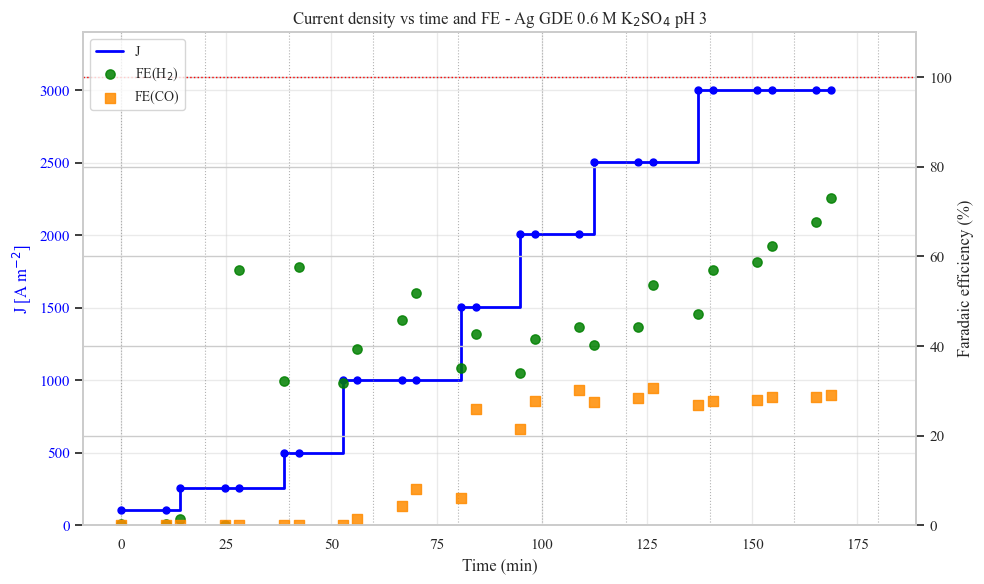

In [577]:
# fig, ax1 = plt.subplots(figsize=(10,6))

# # Primary y-axis: Current Density
# sns.pointplot(data=Book, x='Duration / h', y='Current Density', ax=ax1, color='blue')
# ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.6M_pH3 K2SO4')
# ax1.set_xlabel('Time (h)')
# ax1.set_ylabel(r'J [A m$^{-2}$]', color='blue')
# ax1.set_ylim(0, 3400)
# ax1.set_yticks(np.arange(0, 3400, 500))
# ax1.grid(True)
# ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# # Secondary y-axis: FE_CO
# ax2 = ax1.twinx()
# # Use scatterplot for continuous x-axis
# sns.scatterplot(data=Book, x='Duration / h', y='FE_H2', ax=ax2, color='green', s=40, alpha=0.8)
# ax2.set_ylabel('Faradaic Efficiency (H2) %', color='green')
# ax2.set_ylim(0, 100)
# ax2.set_yticks(np.arange(0, 101, 20))

# plt.tight_layout()
# plt.show()


# Current density and FE against elapsed time - 2026 uGC run
# `rows` (cathode) already carries Duration, Current Density and the FE columns.

d = rows.copy()
d["Duration / min"] = (d["t"] - d["t"].iloc[0]).dt.total_seconds() / 60
d = d.sort_values("Duration / min")

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- primary axis: current density (step profile) ---
ax1.step(d["Duration / min"], d["Current Density"].abs(),
         where="post", color="blue", lw=2, label=r"J")
ax1.scatter(d["Duration / min"], d["Current Density"].abs(),
            color="blue", s=25, zorder=3)

ax1.set_title("Current density vs time and FE - Ag GDE 0.6 M K$_2$SO$_4$ pH 3")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel(r"J [A m$^{-2}$]", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_ylim(0, 3400)
ax1.set_yticks(np.arange(0, 3401, 500))
ax1.grid(True, alpha=0.4)

# step boundaries, so each 20 min block is visible
for b in np.arange(0, d["Duration / min"].max() + 20, 20):
    ax1.axvline(b, color="grey", ls=":", lw=0.8, alpha=0.6)

# --- secondary axis: Faradaic efficiency ---
ax2 = ax1.twinx()
ax2.scatter(d["Duration / min"], d["FE(H2)"], color="green",
            s=45, alpha=0.85, label=r"FE(H$_2$)")
ax2.scatter(d["Duration / min"], d["FE(CO)"], color="darkorange",
            s=45, alpha=0.85, marker="s", label="FE(CO)")

ax2.set_ylabel("Faradaic efficiency (%)")
ax2.set_ylim(0, 110)
ax2.set_yticks(np.arange(0, 111, 20))
ax2.axhline(100, ls=":", color="red", lw=1)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


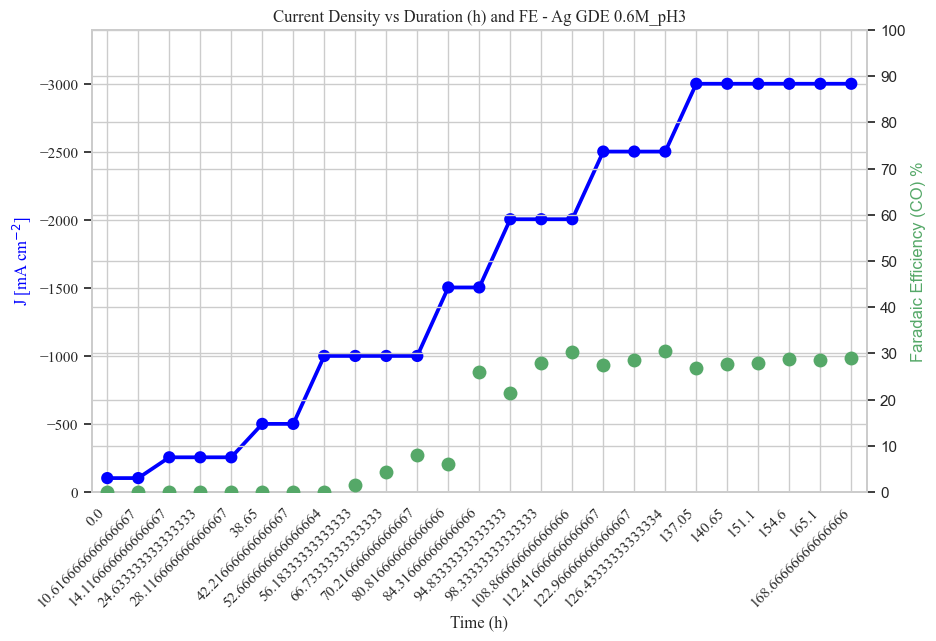

In [578]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=d, x='Duration / min', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.6M_pH3')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=d, x='Duration / min',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240610_Ag_GDE_0_6M_pH3_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Oxygen

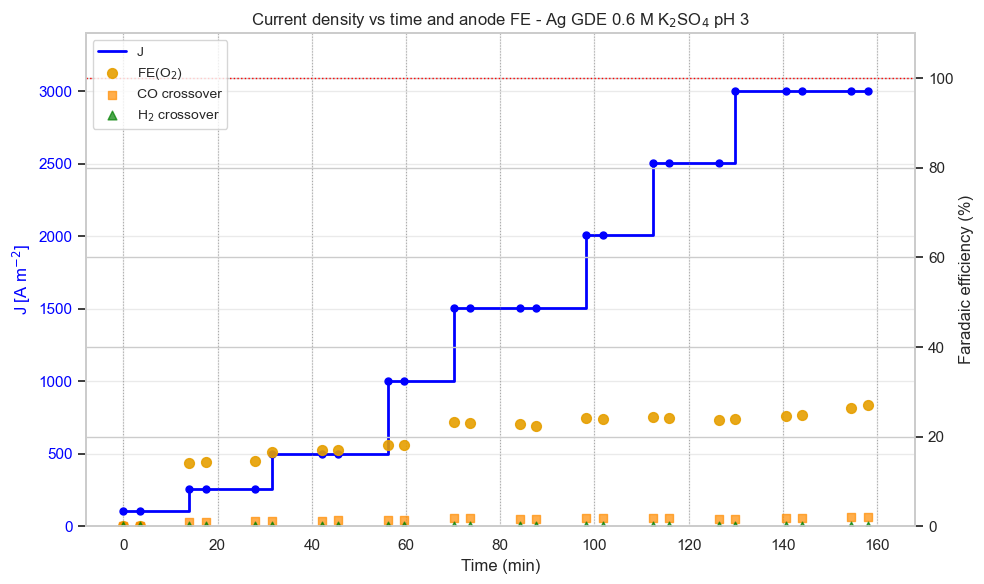

In [579]:
# Current density and anode FE against elapsed time - 2026 uGC run
# `rows_a` (anode) carries Duration, Current Density and the FE columns.

da = rows_a.copy()
da["Duration / min"] = (da["t"] - da["t"].iloc[0]).dt.total_seconds() / 60
da = da.sort_values("Duration / min")

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- primary axis: current density (step profile) ---
ax1.step(da["Duration / min"], da["Current Density"].abs(),
         where="post", color="blue", lw=2, label=r"J")
ax1.scatter(da["Duration / min"], da["Current Density"].abs(),
            color="blue", s=25, zorder=3)

ax1.set_title("Current density vs time and anode FE - Ag GDE 0.6 M K$_2$SO$_4$ pH 3")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel(r"J [A m$^{-2}$]", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_ylim(0, 3400)
ax1.set_yticks(np.arange(0, 3401, 500))
ax1.grid(True, alpha=0.4)

for b in np.arange(0, da["Duration / min"].max() + 20, 20):
    ax1.axvline(b, color="grey", ls=":", lw=0.8, alpha=0.6)

# --- secondary axis: anode Faradaic efficiency ---
ax2 = ax1.twinx()
ax2.scatter(da["Duration / min"], da["FE(O2)"], color="#E69F00",
            s=50, alpha=0.9, label=r"FE(O$_2$)")
ax2.scatter(da["Duration / min"], da["FE(CO)"], color="darkorange",
            s=40, alpha=0.7, marker="s", label="CO crossover")
ax2.scatter(da["Duration / min"], da["FE(H2)"], color="green",
            s=40, alpha=0.7, marker="^", label=r"H$_2$ crossover")

ax2.set_ylabel("Faradaic efficiency (%)")
ax2.set_ylim(0, 110)
ax2.set_yticks(np.arange(0, 111, 20))
ax2.axhline(100, ls=":", color="red", lw=1)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

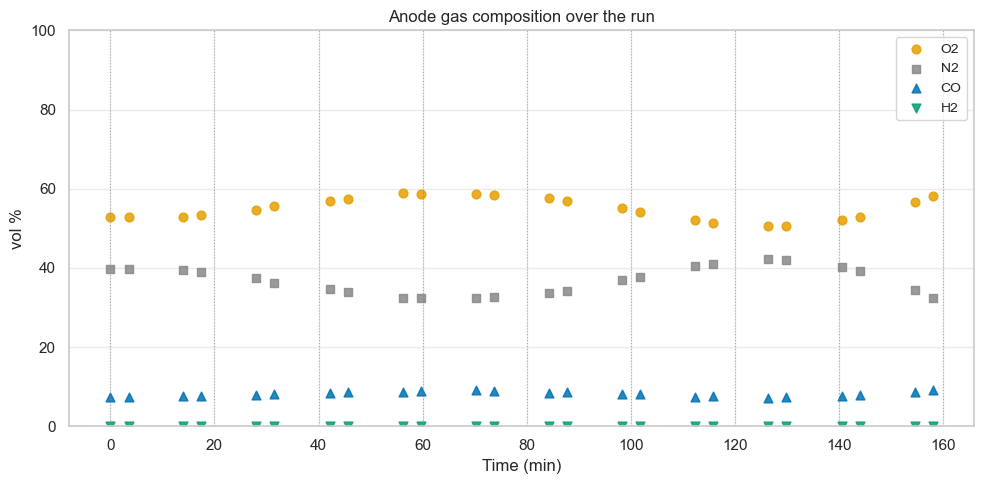

In [580]:
# --- companion: anode stream composition over the same time axis ----------
fig, ax = plt.subplots(figsize=(10, 5))
for g, c, m in [("O2", "#E69F00", "o"), ("N2", "#888888", "s"),
                ("CO", "#0072B2", "^"), ("H2", "#009E73", "v")]:
    ax.scatter(da["Duration / min"], da[f"{g}_vol%"], color=c, marker=m,
               s=40, alpha=0.85, label=g)

for b in np.arange(0, da["Duration / min"].max() + 20, 20):
    ax.axvline(b, color="grey", ls=":", lw=0.8, alpha=0.6)

ax.set_xlabel("Time (min)")
ax.set_ylabel("vol %")
ax.set_title("Anode gas composition over the run")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Current Density vs FE(CO)_ mean and std

# Mean and Standard Deviation Applied Current and FE(CO)

In [581]:
# ===========================================================================
# Res_Book tables - column names matched to the Na2SO4 / K2SO4 CSVs so the
# same plotting code works on this run.
# ===========================================================================

# ---------------------------- CATHODE --------------------------------------
Res_Book_cathode = summary.copy().fillna(0)
Res_Book_cathode = Res_Book_cathode.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",
    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",
    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",
    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",
    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",
    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",
    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",
    # Current density
    "J (A m-2)": "Current Density_mean",
})
Res_Book_cathode["Electrode"] = "cathode"
Res_Book_cathode["Concentration"] = "0.6M"
Res_Book_cathode["pH"] = "pH3"
Res_Book_cathode["Salt"] = "K2SO4"

In [582]:
Res_Book_cathode

,Current Density_mean,FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (min),Electrode,Concentration,pH,Salt
0,102,0.320706,0.000000,0.320706,0.000000,0.025414,0.000000,0.035941,0.000000,0.307998,...,0.012707,0.000000,0.000000,0.012707,0.012707,0-20,cathode,0.6M,pH3,K2SO4
1,255,19.441422,0.000000,1.384619,0.000000,18.750469,0.000000,32.476765,0.000000,0.695179,...,27.774645,0.000000,0.000000,0.689440,27.774645,20-40,cathode,0.6M,pH3,K2SO4
2,501,44.861427,0.000000,44.861427,0.000000,12.659217,0.000000,17.902837,0.000000,38.531818,...,6.329609,0.000000,0.000000,6.329609,6.329609,40-60,cathode,0.6M,pH3,K2SO4
3,1001,42.168190,3.445514,42.557473,2.845905,4.288566,1.781617,8.577133,3.563235,37.430500,...,4.737690,1.762250,2.361858,6.889223,7.099549,60-80,cathode,0.6M,pH3,K2SO4
4,1505,38.941271,16.040343,38.941271,16.040343,3.821376,9.974387,5.404241,14.105913,37.030583,...,1.910688,4.987193,4.987193,6.897881,6.897881,80-100,cathode,0.6M,pH3,K2SO4
5,2007,39.928985,26.534904,41.531156,27.827458,3.104578,2.613014,5.377287,4.525873,37.731933,...,1.395967,3.162046,1.223214,6.961269,2.619181,100-120,cathode,0.6M,pH3,K2SO4
6,2505,46.007840,28.871894,44.234704,28.458268,3.934434,0.911578,6.814639,1.578900,42.244869,...,4.649540,0.458644,1.079084,2.448479,5.728624,120-140,cathode,0.6M,pH3,K2SO4
7,3004,61.001668,28.081463,60.531575,28.203790,3.675104,0.336696,9.002130,0.824733,57.343082,...,5.873422,0.511605,0.456746,3.789179,6.152006,140-160,cathode,0.6M,pH3,K2SO4


In [583]:

# ----------------------------- ANODE ---------------------------------------
# O2 is the anode product; H2 and CO here are crossover from the cathode.
Res_Book_anode = summary_anode.copy().fillna(0)
Res_Book_anode = Res_Book_anode.rename(columns={
    # Mean
    "FE_O2_mean": "FE(O2)_mean",
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    # Median
    "FE_O2_median": "FE(O2)_median",
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    # Median error
    "FE_O2_q25": "FE(O2)_q25",
    "FE_O2_q75": "FE(O2)_q75",
    "FE_O2_err_low": "FE(O2)_err_low",
    "FE_O2_err_high": "FE(O2)_err_high",
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",
    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",
    # SEM
    "FE_O2_sem": "FE(O2)_sem",
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    # Standard deviation
    "FE_O2_std": "FE(O2)_std",
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    # Composition
    "O2_vol_median": "O2_vol%_median",
    "N2_vol_median": "N2_vol%_median",
    "CO_vol_median": "CO_vol%_median",
    "H2_vol_median": "H2_vol%_median",
    "O2_vol_mean":   "O2_vol%_mean",
    "O2_vol_sem":    "O2_vol%_sem",
    # Current density
    "J (A m-2)": "Current Density_mean",
})
Res_Book_anode["Electrode"] = "anode"
Res_Book_anode["Concentration"] = "0.6M"
Res_Book_anode["pH"] = "pH3"
Res_Book_anode["Salt"] = "K2SO4"

In [584]:
Res_Book_anode

,Current Density_mean,FE(O2)_mean,FE(O2)_median,FE(O2)_sem,FE(O2)_std,FE(O2)_q25,FE(O2)_q75,FE(H2)_mean,FE(H2)_median,FE(H2)_sem,...,FE(O2)_err_high,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,Time Interval (min),Electrode,Concentration,pH,Salt
0,102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0-20,anode,0.6M,pH3,K2SO4
1,255,14.295566,14.255334,0.119612,0.207174,14.183396,14.387619,0.002003,0.001938,0.000102,...,0.132286,0.000035,0.000132,0.008006,0.022237,20-40,anode,0.6M,pH3,K2SO4
2,501,16.818082,16.909937,0.143265,0.248142,16.723523,16.958569,0.002938,0.003024,0.000118,...,0.048632,0.000160,0.000031,0.017410,0.014537,40-60,anode,0.6M,pH3,K2SO4
3,1001,18.119449,18.119449,0.032476,0.045928,18.103211,18.135687,0.003430,0.003430,0.000043,...,0.016238,0.000021,0.000021,0.013649,0.013649,60-80,anode,0.6M,pH3,K2SO4
4,1505,22.875452,22.902752,0.185317,0.370635,22.643271,23.134933,0.004376,0.004386,0.000024,...,0.232181,0.000021,0.000011,0.042179,0.036971,80-100,anode,0.6M,pH3,K2SO4
5,2007,24.057974,24.057974,0.182737,0.258430,23.966605,24.149342,0.006013,0.006013,0.000226,...,0.091369,0.000113,0.000113,0.003196,0.003196,100-120,anode,0.6M,pH3,K2SO4
6,2505,24.041570,24.064969,0.212129,0.367418,23.863990,24.230849,0.012016,0.010879,0.001787,...,0.165880,0.000614,0.002320,0.021228,0.008966,120-140,anode,0.6M,pH3,K2SO4
7,3004,25.346773,24.853501,0.573203,1.281720,24.551250,26.404440,0.025182,0.024729,0.002357,...,1.550939,0.001345,0.004375,0.049152,0.180130,140-160,anode,0.6M,pH3,K2SO4


In [585]:
Res_Book_cathode
# Res_Book_cathode.to_csv("20260402_0.6M K2SO4_pH3_cathode.csv", index=False)
# Res_Book_anode.to_csv("20260402_0.6M K2SO4_pH3_anode.csv", index=False)

,Current Density_mean,FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (min),Electrode,Concentration,pH,Salt
0,102,0.320706,0.000000,0.320706,0.000000,0.025414,0.000000,0.035941,0.000000,0.307998,...,0.012707,0.000000,0.000000,0.012707,0.012707,0-20,cathode,0.6M,pH3,K2SO4
1,255,19.441422,0.000000,1.384619,0.000000,18.750469,0.000000,32.476765,0.000000,0.695179,...,27.774645,0.000000,0.000000,0.689440,27.774645,20-40,cathode,0.6M,pH3,K2SO4
2,501,44.861427,0.000000,44.861427,0.000000,12.659217,0.000000,17.902837,0.000000,38.531818,...,6.329609,0.000000,0.000000,6.329609,6.329609,40-60,cathode,0.6M,pH3,K2SO4
3,1001,42.168190,3.445514,42.557473,2.845905,4.288566,1.781617,8.577133,3.563235,37.430500,...,4.737690,1.762250,2.361858,6.889223,7.099549,60-80,cathode,0.6M,pH3,K2SO4
4,1505,38.941271,16.040343,38.941271,16.040343,3.821376,9.974387,5.404241,14.105913,37.030583,...,1.910688,4.987193,4.987193,6.897881,6.897881,80-100,cathode,0.6M,pH3,K2SO4
5,2007,39.928985,26.534904,41.531156,27.827458,3.104578,2.613014,5.377287,4.525873,37.731933,...,1.395967,3.162046,1.223214,6.961269,2.619181,100-120,cathode,0.6M,pH3,K2SO4
6,2505,46.007840,28.871894,44.234704,28.458268,3.934434,0.911578,6.814639,1.578900,42.244869,...,4.649540,0.458644,1.079084,2.448479,5.728624,120-140,cathode,0.6M,pH3,K2SO4
7,3004,61.001668,28.081463,60.531575,28.203790,3.675104,0.336696,9.002130,0.824733,57.343082,...,5.873422,0.511605,0.456746,3.789179,6.152006,140-160,cathode,0.6M,pH3,K2SO4


In [586]:
summary_anode

,J (A m-2),FE_O2_mean,FE_O2_median,FE_O2_sem,FE_O2_std,FE_O2_q25,FE_O2_q75,FE_H2_mean,FE_H2_median,FE_H2_sem,...,c_H2_median,V_median,n,FE_O2_err_low,FE_O2_err_high,FE_H2_err_low,FE_H2_err_high,FE_CO_err_low,FE_CO_err_high,Time Interval (min)
0,102,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000138,2.19,2,0.0,0.0,0.0,0.0,0.0,0.0,0-20
1,255,14.295566,14.255334,0.119612,0.207174,14.183396,14.387619,0.002003,0.001938,0.000102,...,0.000149,2.55,3,0.071937,0.132286,0.000035,0.000132,0.008006,0.022237,20-40
2,501,16.818082,16.909937,0.143265,0.248142,16.723523,16.958569,0.002938,0.003024,0.000118,...,0.000207,3.03,3,0.186414,0.048632,0.00016,0.000031,0.01741,0.014537,40-60
3,1001,18.119449,18.119449,0.032476,0.045928,18.103211,18.135687,0.00343,0.00343,0.000043,...,0.000224,3.59,2,0.016238,0.016238,0.000021,0.000021,0.013649,0.013649,60-80
4,1505,22.875452,22.902752,0.185317,0.370635,22.643271,23.134933,0.004376,0.004386,0.000024,...,0.000222,3.95,4,0.259482,0.232181,0.000021,0.000011,0.042179,0.036971,80-100
5,2007,24.057974,24.057974,0.182737,0.258430,23.966605,24.149342,0.006013,0.006013,0.000226,...,0.000272,4.24,2,0.091369,0.091369,0.000113,0.000113,0.003196,0.003196,100-120
6,2505,24.04157,24.064969,0.212129,0.367418,23.863990,24.230849,0.012016,0.010879,0.001787,...,0.000462,4.46,3,0.200978,0.16588,0.000614,0.00232,0.021228,0.008966,120-140
7,3004,25.346773,24.853501,0.573203,1.281720,24.551250,26.404440,0.025182,0.024729,0.002357,...,0.001036,4.72,5,0.302251,1.550939,0.001345,0.004375,0.049152,0.18013,140-160


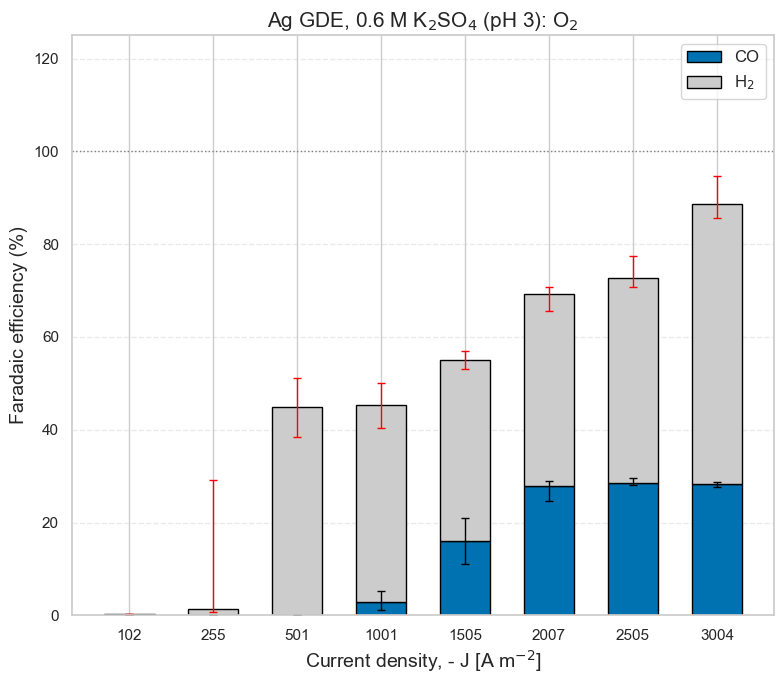

In [587]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 3): O$_2$", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

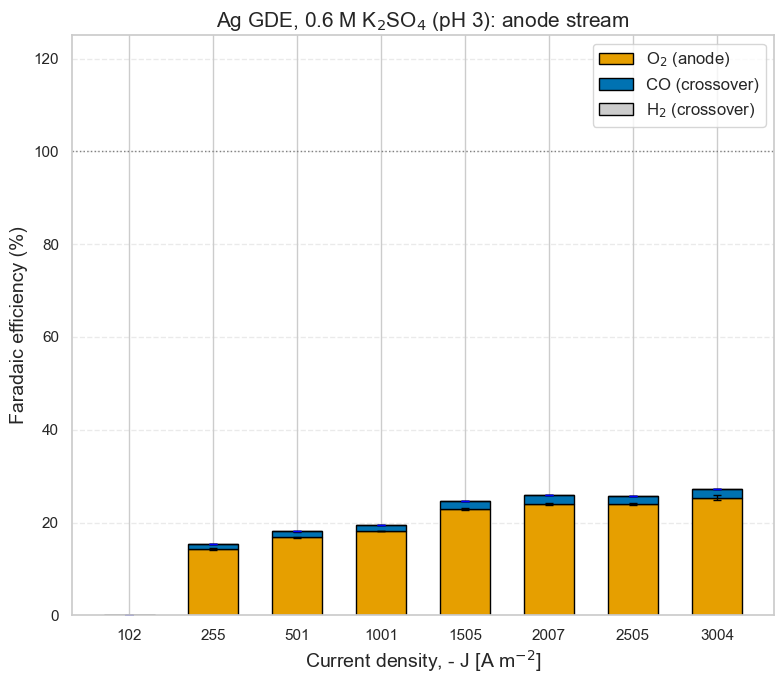

In [588]:
color_O2 = "#E69F00"
color_CO = "#0072B2"
color_H2 = "#CCCCCC"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary_anode))
w = 0.6

O2 = summary_anode["FE_O2_mean"]
CO = summary_anode["FE_CO_mean"]
H2 = summary_anode["FE_H2_mean"]

# O2 bottom - the anode product
ax.bar(x, O2, w, color=color_O2, edgecolor="black", lw=1, label=r"O$_2$ (anode)")
# CO stacked - crossover from the cathode
ax.bar(x, CO, w, bottom=O2,
       color=color_CO, edgecolor="black", lw=1, label="CO (crossover)")
# H2 stacked - crossover from the cathode
ax.bar(x, H2, w, bottom=O2 + CO,
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$ (crossover)")

# error bars at the top of each segment
ax.errorbar(x, O2, yerr=summary_anode["FE_O2_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.errorbar(x, O2 + CO, yerr=summary_anode["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.errorbar(x, O2 + CO + H2, yerr=summary_anode["FE_H2_sem"],
            fmt="none", ecolor="blue", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(summary_anode["J (A m-2)"])
ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 3): anode stream", fontsize=15)
ax.set_ylim(0, max(125, (O2 + CO + H2).max()*1.15))
ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_anode_O2_CO_H2_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Mean and StD of FE(CO) through time

In [589]:
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot FE (CO) mean with standard deviation
# ax.errorbar(Res_Book.index, Res_Book['FE_CO_mean'], 
#             yerr=Res_Book['FE_CO_std'], fmt='-o', label='0.6M_pH3 K2SO4 (22C)')

# # Formatting the plot
# ax.set_xlabel('Time')
# ax.set_ylabel('FE(CO) %')
# ax.set_title('Mean and Standard Deviation of FE(CO)')
# ax.set_ylim(0,100)
# ax.legend()
# ax.grid(False)

# # plt.savefig('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_time.png', dpi=300, bbox_inches='tight')
# plt.show()

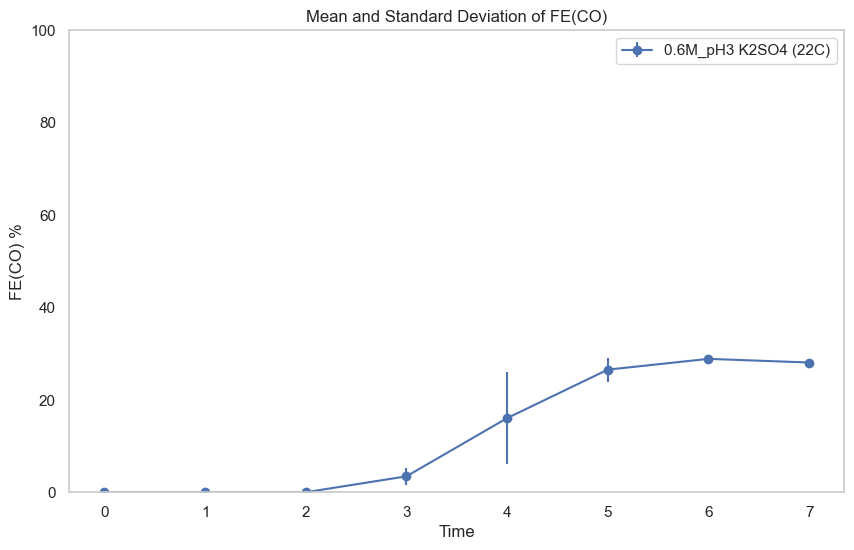

In [590]:
## SEM error

fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book_cathode.index, Res_Book_cathode['FE(CO)_mean'], 
            yerr=Res_Book_cathode['FE(CO)_sem'], fmt='-o', label='0.6M_pH3 K2SO4 (22C)')


# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_time_SEM.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

In [591]:
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot FE (CO) mean with standard deviation against Applied Current mean
# ax.errorbar(Res_Book['Current Density_mean'], Res_Book['FE_CO_mean'], 
#             yerr=Res_Book['FE_CO_std'], fmt='-o', label='0.6M_pH3 K$_2$SO$_4$ (22°C)')

# # Formatting the plot
# ax.set_xlabel(r'- J [A m$^{-2}$]')
# ax.set_ylabel('FE(CO) %')
# ax.set_xlim(0,3100)
# ax.set_ylim(0,100)
# ax.set_title('Faradaic Efficiency towards CO vs. Current Density') # Every 20 min
# ax.legend()
# ax.grid(False)
# plt.tight_layout()

# # plt.savefig('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
# plt.show()

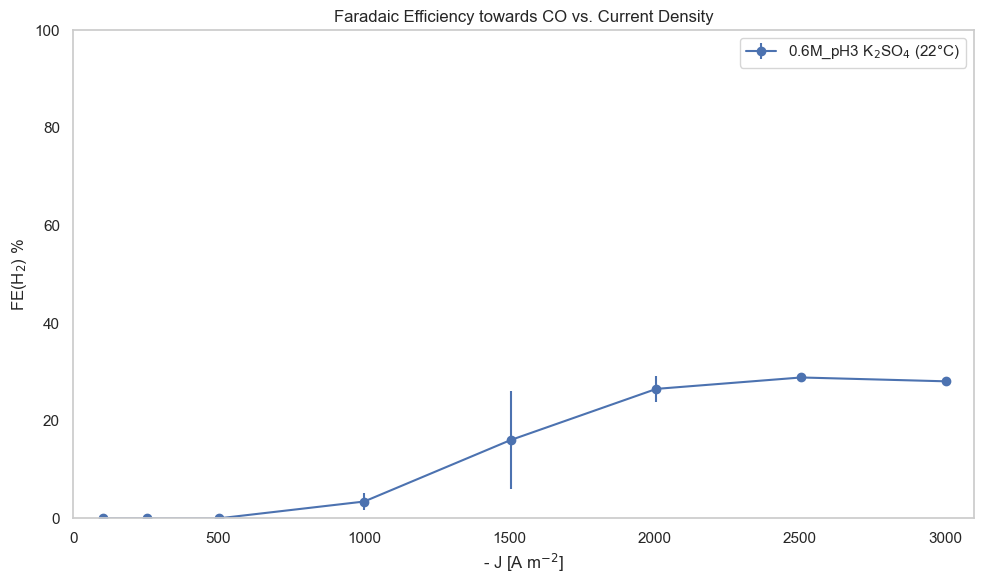

In [592]:
#SEM error
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book_cathode['Current Density_mean'], Res_Book_cathode['FE(CO)_mean'], 
            yerr=Res_Book_cathode['FE(CO)_sem'], fmt='-o', label='0.6M_pH3 K$_2$SO$_4$ (22°C)')

# Formatting the plot
ax.set_xlabel(r'- J [A m$^{-2}$]')
ax.set_ylabel('FE(H$_2$) %')
ax.set_xlim(0,3100)
ax.set_ylim(0,100)
ax.set_title('Faradaic Efficiency towards CO vs. Current Density') # Every 20 min
ax.legend()
ax.grid(False)
plt.tight_layout()

# plt.savefig('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(CO)vsCD_SEM.png', dpi=300, bbox_inches='tight')
plt.show()

In [593]:
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot FE (CO) mean with standard deviation against Applied Current mean
# # ax.errorbar(Res_Book['Current Density_mean'], Res_Book['FE_H2_c_mean'], 
# #             yerr=Res_Book['FE_H2_std'], fmt='-o', label='0.6M_pH3 K$_2$SO$_4$ (22°C)')


# ax.errorbar(Res_Book['Current Density_mean'], Res_Book['FE_H2_mean'], 
#             yerr=Res_Book['FE_H2_std'], fmt='-o', label='0.6M_pH3 K$_2$SO$_4$ (22°C)')

# # Formatting the plot
# ax.set_xlabel(r'- J [A m$^{-2}$]')
# ax.set_ylabel('FE(H$_2$) %')
# ax.set_xlim(0,3100)
# ax.set_ylim(0,101)
# ax.set_title('Faradaic Efficiency towards H$_2$ vs. Current Density') # Every 20 min
# ax.legend(loc = "upper right", bbox_to_anchor=(1, 0.94))
# ax.grid(False)
# plt.tight_layout()

# # plt.savefig('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(H2)vsCD.png', dpi=300, bbox_inches='tight')
# plt.show()

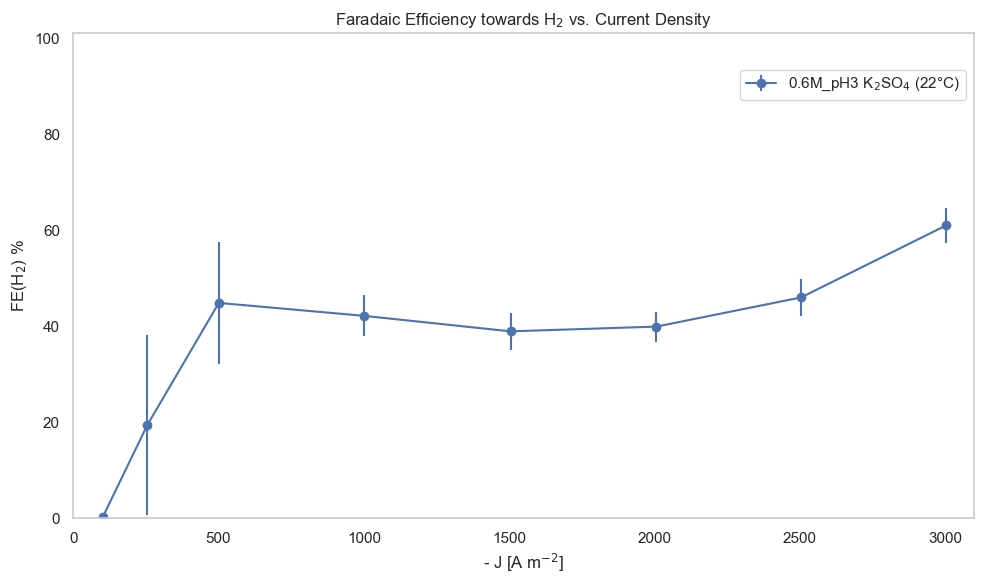

In [594]:
## SEM error
fig, ax = plt.subplots(figsize=(10, 6))

# ax.errorbar(Res_Book['Current Density_mean'], Res_Book['FE_H2_mean'], 
#             yerr=Res_Book['FE_H2_std'], fmt='-o', label='0.45M_pH6 Li$_2$SO$_4$-MeOH (-15°C)')

ax.errorbar(Res_Book_cathode['Current Density_mean'], Res_Book_cathode['FE(H2)_mean'], 
            yerr=Res_Book_cathode['FE(H2)_sem'], fmt='-o', label='0.6M_pH3 K$_2$SO$_4$ (22°C)')

# Formatting the plot
ax.set_xlabel(r'- J [A m$^{-2}$]')
ax.set_ylabel('FE(H$_2$) %')
ax.set_xlim(0,3100)
ax.set_ylim(0,101)
ax.set_title('Faradaic Efficiency towards H$_2$ vs. Current Density') # Every 20 min
ax.legend(loc = "upper right", bbox_to_anchor=(1, 0.94))
ax.grid(False)
plt.tight_layout()

# plt.savefig('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(H2)vsCD_SEM.png', dpi=300, bbox_inches='tight')
# plt.show()

# Mean and Standard Deviation Applied Current and FE(O2)

In [373]:
# # Ensure FE_H2 is consistent with FE_CO
# # Book2["FE_H2_c"] = 100 - Book2["FE_CO"] #Ensure thatt both are less than 100

# # Only keep currents up to 3 A
# # Book2 = Book2[Book2["Applied current / A"] <= 3].copy()

# Book["FE_O2"] = Book["FE_O2"].rolling(window=3, center=True).mean()

# Res_Book_o2 = Book.groupby('Applied current / A').agg({
#     'Current Density': ['mean', 'std'],
#     'FE_O2': ['mean', 'std']
# })

# Res_Book_o2.columns = ['_'.join(col) for col in Res_Book_o2.columns]


# ### SEM instead of STD (much better for small n)
# Res_Book_o2['FE_O2_sem'] = (
#     Res_Book_o2['FE_O2_std'] / np.sqrt(3)
# )


# # # Group by applied current and calculate mean and std
# # Res_Book_o2 = Book.groupby('Applied current / A').agg({
# #     'Current Density': ['mean', 'std'],
# #     'FE_O2': ['mean', 'std'],
# #     # 'FE_H2_c': ['mean', 'std']
# # })

# # # Flatten MultiIndex columns
# # Res_Book_o2.columns = ['_'.join(col) for col in Res_Book_o2.columns]

# Res_Book_o2 = Res_Book_o2.reset_index()
# Res_Book_o2 = Res_Book_o2.fillna(0)
# print(Res_Book_o2)

In [374]:
# Res_Book_o2
# # Res_Book_o2.to_csv('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_O2.csv')

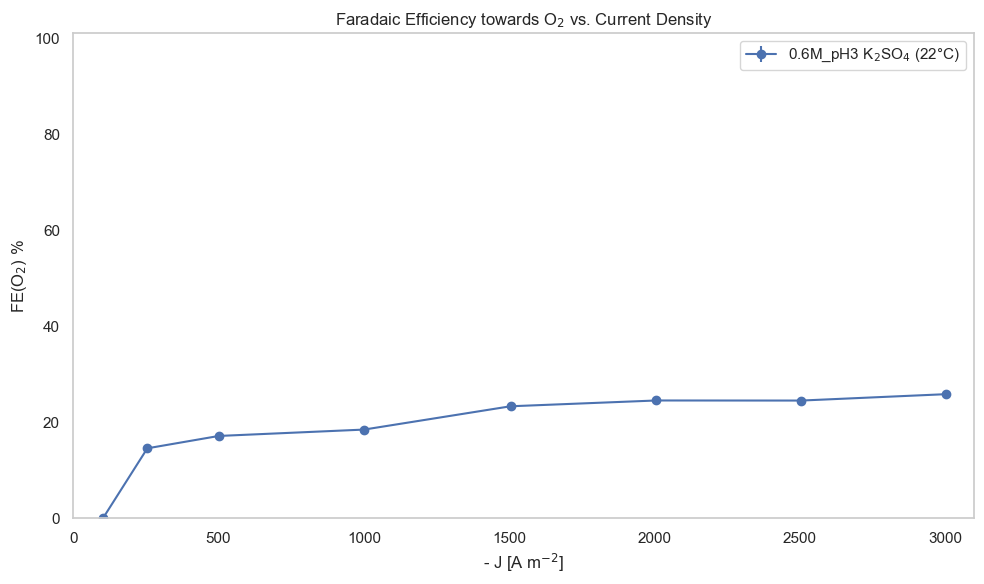

In [375]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book_anode['Current Density_mean'], Res_Book_anode['FE(O2)_mean'], 
            yerr=Res_Book_anode['FE(O2)_sem'], fmt='-o', label='0.6M_pH3 K$_2$SO$_4$ (22°C)')

# ax.errorbar(
#     Res_Book_o2['Current Density_mean'],
#     Res_Book_o2['FE_O2_smooth_mean'],
#     yerr=Res_Book_o2['FE_O2_smooth_std'],
#     fmt='o-',
#     capsize=4,
#     elinewidth=1.5,
#     markerfacecolor='white'
# )

# Formatting the plot
ax.set_xlabel(r'- J [A m$^{-2}$]')
ax.set_ylabel('FE(O$_2$) %')
ax.set_xlim(0,3100)
ax.set_ylim(0,101)
ax.set_title('Faradaic Efficiency towards O$_2$ vs. Current Density') # Every 20 min
ax.legend()
ax.grid(False)
plt.tight_layout()

# plt.savefig('20260402 - Ag60 GDE_RT_K2SO4-water_pH3_mean_std_FE(O2)vsCD_SEM.png', dpi=300, bbox_inches='tight')
plt.show()